# Separations Computer Project

By Kevin (Won June) Cho
====
Due 4/7/21: (Received Extension)
----

In [1]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [2]:
# First, import all necessary packages/scripts for the entire project:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import math
import sympy as sym
from matplotlib import cm
import matplotlib.colors
from matplotlib.colors import ListedColormap
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.integrate import odeint
from get_antoine_coefficient import get_antoine_coefficient
from redlich_kwong_kvalue import redlich_kwong_kvalue

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.style.use('default')
# Make images higher resolution and set default size
matplotlib.rcParams['figure.dpi'] = 200
matplotlib.rcParams['figure.figsize'] = (4, 4)

Part A: Reading and data inspection (15 points)
----

1) Answer in markdown text, why are Mustain, et al. measuring the VLE of acetone/isobutanol?
----

1) Mustain, et al. are measuring the VLE of acetone/isobutanol mainly because accurate binary VLE interaction parameters are important to have for optimal design of distillation columns. Distillation columns here are for bioethanol industries, where bioethanol fermentation products are separated. Bioethanol itself is popular to use as a fossil-fuel alternative, but has fermentation (by)products, and to create optimal distillation columns to separate these byproducts, we need accurate interaction parameters. And in those specific interaction parameters, this is specifically for the VLE of acetone and isobutanol. This is because in literature right now, there are no acetone/isobutanol VLE data at atmospheric pressure available.

2) Answer in markdown text, describe the experimental setup the authors used to measure the VLE. Provide one additional consideration behind the design of the modified Othmer recirculation still, according to what you read in Morrison, et al. (5 points)
-----

2) This is explained in the "Methodology" section of the article. First, pure acetone and isobutanol were bought. Then, modified Othmer recirculation still was used to obtain the boiling temperatures, which in turn allowed to obtain isobaric VLE data. Then, a mixture with known, certain compositions of acetone and isobutanol was prepared in put into an ebulliometer. Experiment was controlled so that the total volume was constant (150 cm^3) and proper mixing and heating happened thanks to the magnetic stirrer. After the mixture was in, if the temperature and pressure in the ebulliometer stayed constant for an hour, equilibrium was assumed and a sample at this stage was taken. Lastly, gas chromatograph analysis was used on this sample to analyze its composition. This composition data would allow Mustain, et al. to complete their VLE analysis. 

According to Morrison, et al., one additional consideration behind the design of the modified Othmer recirculation still is that the internal vapor jacket was lengthened. The original jacket was short to minimize heat loss and prevent reflux, but had a possibility of the salt particles getting carried over to the condensed vapor chambers, which would pose a big problem. Therefore, by lengthening the jacket, this problem was eliminated– but a longer vapor jacket meant that reflux may happen easier. To prevent reflux, an electrical heating tape was wrapped around the jacket to increase the temperature by 2-3 degrees Celsius. 

3) Plot VLE data (.csv made from Table 1) in Txy diagram. Which species is the light key (by convention), and why? Provide appropriate axes, legend, and title.
----

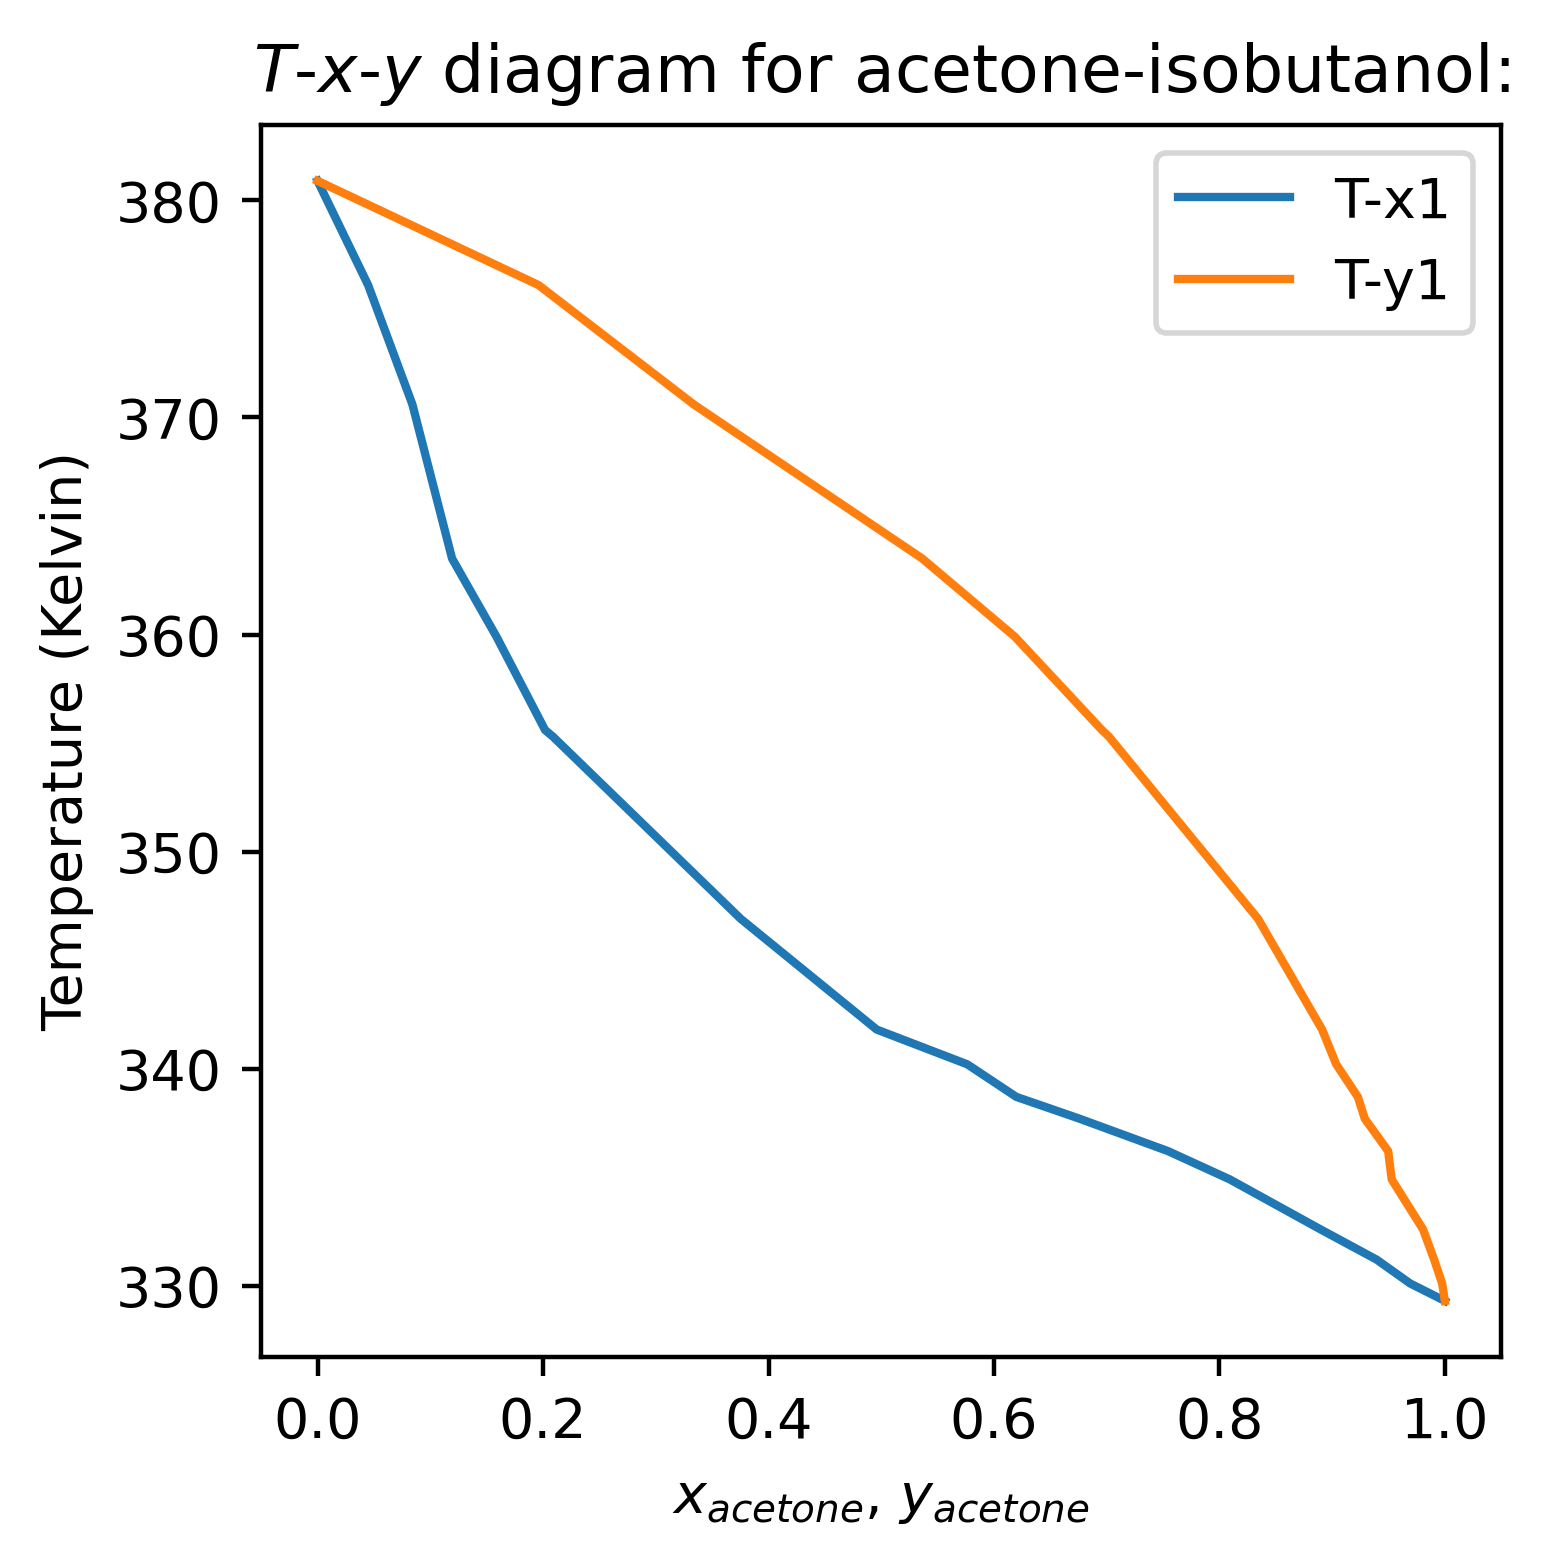

In [3]:
# Read in the csv file:
data = pd.read_csv("VLE_acetone_isobutanol.csv")

# Assign temp, x1, y1 values:
Temp = data["T (K)"]
x1 = data["x1"]
y1 = data["y1"]

# Then plot the T-x-y diagram: 
plt.plot(x1,Temp, label = 'T-x1')
plt.plot(y1,Temp, label = 'T-y1')
plt.legend()
plt.title('$T$-$x$-$y$ diagram for acetone-isobutanol:')
plt.xlabel('$x_{acetone}$, $y_{acetone}$') # acetone is light key
plt.ylabel('Temperature (Kelvin)')
plt.show()

Description: Above is the VLE diagram (T-x-y diagram) for acetone-isobutanol binary system. Acetone is light key by convention, as it has a lower boiling point compared to isobutanol. (Acetone BP 329.1 K vs Isobutanol BP 381.1 K). Axes, legend, and title are in the diagram above. 

# Part B: VLE predictions

# 1) Predict the VLE for acetone/isobutanol at 1 atm using a) Redlich-Kwong EOS, b) Soave Redlich-Kwong EOS, and c) Raoult’s Law. In a separate markdown cell, provide citations for the parameters you use in the EOS and in Antoine’s equation.
----

A) Using the Redlich-Kwong EOS:
---

In [4]:
# define a residual function for Redlich-Kwong EOS:
def resfunRK(T,Tc, Pc, P_Pa, x, y, z):
    return 1-np.sum(redlich_kwong_kvalue(Tc, Pc, T, P_Pa, x, y)*z )

In [5]:
# our molecules of interest:
molecules = ['acetone','isobutanol']

P_bar = 1.01325  # Pressure in bar
P_Pa = P_bar * 1e5
Tguess = 325 # Tguess in K

# Critical temperature, K - found it on NIST for acetone, isobutanol
Tc = np.array([508.0, 548.0]) 

# Critical pressure, Pa - found it on NIST and converted it from bar 
# to Pa for acetone, isobutanol

Pc = np.array([48.0, 45.0])*1e5 

# redlich_kwong_kvalue needs a guess for initial liquid and vapor 
# compositions, [acetone, isobutanol]:
y_guess = [0, 1]

T_RK = []
x_acetone_RK = np.linspace(0,1)
y_acetone_RK = []
for x in x_acetone_RK:
    # As we go through the for loop for each composition, we'll 
    # define new values for z.
    # In this case, we have z = [x_acetone, x_isobutanol], or [x , 1 - x]
    # for the binary system.
    # We're still using z here, because this is for the residual function:
    z = [x, 1-x]
    x_array = z
    T = fsolve(resfunRK, Tguess, args=(Tc, Pc, P_Pa, x_array, y_guess,
                                       z))
    T_RK.append(T)
    K = redlich_kwong_kvalue(Tc, Pc, T, P_Pa, x_array, y_guess)
    y = K*z
    y_acetone_RK.append(y[0])
    
    # before repeating the loop, update y_guess and T_guess:
    y_guess = y 
    Tguess = T    

Citations for Tc and Pc for acetone and isobutanol: <br>
For acetone: https://webbook.nist.gov/cgi/cbook.cgi?ID=C67641&Units=SI&Mask=4#Thermo-Phase <br>
For isobutanol: https://webbook.nist.gov/cgi/cbook.cgi?ID=C78831&Units=SI&Mask=4#Thermo-Phase


B) Using the Soave Redlich-Kwong EOS:
---

In [6]:
# define a residual function for Redlich-Kwong EOS:
def resfunSRK(T,Tc, Pc, P_Pa, x, y, w, z):
    return 1-np.sum(redlich_kwong_kvalue(Tc, Pc, T, P_Pa, x, y, w)*z )

In [7]:
molecules = ['acetone','isobutanol']

P_bar = 1.01325  # Pressure in bar
P_Pa = P_bar * 1e5
Tguess = 325 # Tguess in K

# Critical temperature, K - found it on NIST for acetone, isobutanol
Tc = np.array([508.0, 548.0]) 

# Critical pressure, Pa - found it on NIST and converted it from bar 
# to Pa for acetone, isobutanol

Pc = np.array([48.0, 45.0])*1e5 

# Acentric factor, w - found it on a website, look at markdown text below
# for citations.
w = np.array([0.304,0.592])

# redlich_kwong_kvalue needs a guess for initial liquid and vapor 
# compositions, [acetone, isobutanol]:
y_guess = [0, 1]

T_SRK = []
x_acetone_SRK = np.linspace(0,1)
y_acetone_SRK = []
for x in x_acetone_SRK:
    # As we go through the for loop for each composition, we'll 
    # define new values for z.
    # In this case, we have z = [x_acetone, x_isobutanol], or [x , 1 - x]
    # for the binary system.
    # We're still using z here, because this is for the residual function:
    z = [x, 1-x]
    x_array = z
    T = fsolve(resfunSRK, Tguess, args=(Tc, Pc, P_Pa, x_array, y_guess, w,
                                       z))
    T_SRK.append(T)
    K = redlich_kwong_kvalue(Tc, Pc, T, P_Pa, x_array, y_guess, w)
    y = K*z
    y_acetone_SRK.append(y[0])
    
    # before repeating the loop, update y_guess and T_guess:
    y_guess = y 
    Tguess = T    

Citations for Tc and Pc for acetone and isobutanol: <br>
For acetone: https://webbook.nist.gov/cgi/cbook.cgi?ID=C67641&Units=SI&Mask=4#Thermo-Phase <br>
For isobutanol: https://webbook.nist.gov/cgi/cbook.cgi?ID=C78831&Units=SI&Mask=4#Thermo-Phase

Citations for w (Acentric factor) for acetone and isobutanol: <br>
For both acetone and isobutanol: http://www.kaylaiacovino.com/Petrology_Tools/Critical_Constants_and_Acentric_Factors.htm

C) Using Raoult's Law:
---

In [8]:
# define a residual function for Raoult's Law, which is our bubble point equation:

def resfunRAO(T,P_bar,AntoineCoeffs,z):
    return 1-np.sum(raoult_kvalue(T,P_bar,AntoineCoeffs)*z)

In [9]:
# Then, we set up a function for K_i from Raoult's Law:

def raoult_kvalue(T, P, AntoineCoeffs):
    # This function calculates saturation the K-value 
    # for a list of species.
    # This needs an Nx3 matrix of Antoine coefficients,
    # where each of N rows is a different molecule (N=2 ,
    # in this case) and each molecule has 3 coefficients
    # in its row.  
    Ps = antoine(T, AntoineCoeffs)
    K = Ps/P
    return K

In [10]:
# Then, set up a function for Antoine's equation:

def antoine(T, coeff):
    # This function returns saturation pressure Ps for a species, 
    # given A, B, and C
    # It takes T and an Nx3 matrix of Antoine coefficients,
    # This makes a vector for each coefficient a, b, and c, 
    # each containing N entries for N molecules
    # Note - we need this to work on multiple molecules at once, 
    # because of our above objective function
    a = coeff[:,0]
    b = coeff[:,1]
    c = coeff[:,2]
    
    Ps = 10.0**( a - (b / ( T + c ) ) )
    
    return Ps

In [11]:
# Then, grab Antoine coefficients from NIST: (therefore the
# citation is the NIST, which is the same as before)

def antoine_list(molecule_list,temp):
    As,Bs,Cs,Tmins,Tmaxs = [],[],[],[],[]
    for molecule in molecule_list:
        A,B,C,Tmin,Tmax = get_antoine_coefficient(molecule,temp)
        print('Found coefficients for %s: %s, %s, %s' % (molecule,
                                                         A, B, C))
        As.append(A)
        Bs.append(B)
        Cs.append(C)
        Tmins.append(Tmin)
        Tmaxs.append(Tmax)

    AntoineCoeffs = np.array([As, Bs, Cs]).transpose()
    return AntoineCoeffs

In [12]:
# Now that we have set up our needed functions, we just need to run it:

P_bar = 1.01325  # Pressure in bar 
Tguess = 360 # we guess 360K for temperature
molecules = ['acetone','isobutanol'] 

#find Antoine coefficients for our molecules
AntoineCoeffs = antoine_list(molecules,Tguess) 
T_RAO = []
x_acetone_RAO = np.linspace(0,1)
y_acetone_RAO = []
for x in x_acetone_RAO:
    # As we go through the for loop for each composition, 
    # we'll define new values for z.
    # In this case, we have z = [x_acetone, x_isobutanol], 
    # or [x , 1 - x] for the binary system
    z = [x, 1-x]
    T = fsolve(resfunRAO, Tguess, args=(P_bar,AntoineCoeffs,z))
    T_RAO.append(T)
    K = raoult_kvalue(T, P_bar, AntoineCoeffs)
    y = K*z
    y_acetone_RAO.append(y[0])
    # Update Tguess
    Tguess = T


Found coefficients for acetone: 4.42448, 1312.253, -32.445
Found coefficients for isobutanol: 4.43126, 1236.991, -101.528


Citations for Antoine coefficients: The pre-made get_antoine_coefficient grabs coefficients
from the NIST webbook. <br>
Acetone: https://webbook.nist.gov/cgi/cbook.cgi?ID=C67641&Units=SI&Mask=4#Thermo-Phase <br>
Isobutanol: https://webbook.nist.gov/cgi/cbook.cgi?ID=C78831&Units=SI&Mask=4#Thermo-Phase

# 2) Using the non-random two liquid (NRTL) activity coefficient model and modified Raoult’s Law, predict the acetone/isobutanol VLE. (Hint: these results should agree with in Figure 1 of Mustain, et al.)

In [13]:
#First, raoult's law:
def antoine_list(molecule_list,temp):
    As,Bs,Cs,Tmins,Tmaxs = [],[],[],[],[]
    for molecule in molecule_list:
        A,B,C,Tmin,Tmax = get_antoine_coefficient(molecule,temp)
        As.append(A)
        Bs.append(B)
        Cs.append(C)
        Tmins.append(Tmin)
        Tmaxs.append(Tmax)
    AntoineCoeffs = np.array([As, Bs, Cs]).transpose()
    return AntoineCoeffs
        
def antoine(T, coeff):
    a = coeff[:,0]
    b = coeff[:,1]
    c = coeff[:,2] 
    Ps = 10.0**( a - (b / ( T + c ) ) )
    return Ps

In [14]:
#A's and B's:
parameters = np.array([-21.7830 ,41.0996,  7435.71 , -13737.39]) 

# Then define NRTLactivity function:
def NRTLactivity(T, x, parameters):
    tau12 = parameters[0] + parameters[2]/T
    tau21 = parameters[1] + parameters[3]/T
    G12 = math.exp(-0.3*tau12)
    G21 = math.exp(-0.3*tau21)
    gamma1 = math.exp((x[1]**2)*(tau21*(G21/(x[0]+x[1]*G21))**2 + (tau12*G12)/((x[1]+x[0]*G12)**2)))
    gamma2 = math.exp((x[0]**2)*(tau12*(G12/(x[1]+x[0]*G12))**2 + (tau21*G21)/((x[0]+x[1]*G21)**2)))
    Activity_Coeffs = np.array([gamma1, gamma2])
    return Activity_Coeffs

In [15]:
# Then define modified raoult's law:
def modified_raoult_kvalue(T, P, AntoineCoeffs, x, parameters):
    Ps = antoine(T, AntoineCoeffs)
    gamma = NRTLactivity(T, x, parameters)
    return (Ps/P)*gamma

In [16]:
# Then define our residual function:
def resfunNRTL(T,P_bar,AntoineCoeffs,z,parameters):
    return 1-np.sum(modified_raoult_kvalue(T,P_bar,AntoineCoeffs,z,parameters)*z)

In [17]:
P_bar = 1.01325
Tguess = 354
molecules = ['Acetone', 'Isobutanol']
AntoineCoeffs = antoine_list(molecules,Tguess)

T_soln2 = []
x_acetone_NRTL = np.linspace(0,1)
y_acetone_NRTL = []
for x in x_acetone_NRTL:
    z =np.array([x, 1-x]) 
    T = fsolve(resfunNRTL, Tguess, args = (P_bar, AntoineCoeffs, z, parameters))
    T_soln2.append(T)
    y = modified_raoult_kvalue(T, P_bar, AntoineCoeffs, z, parameters)*z
    y_acetone_NRTL.append(y[0])
    Tguess = T

Text(0, 0.5, 'Temperature [K]')

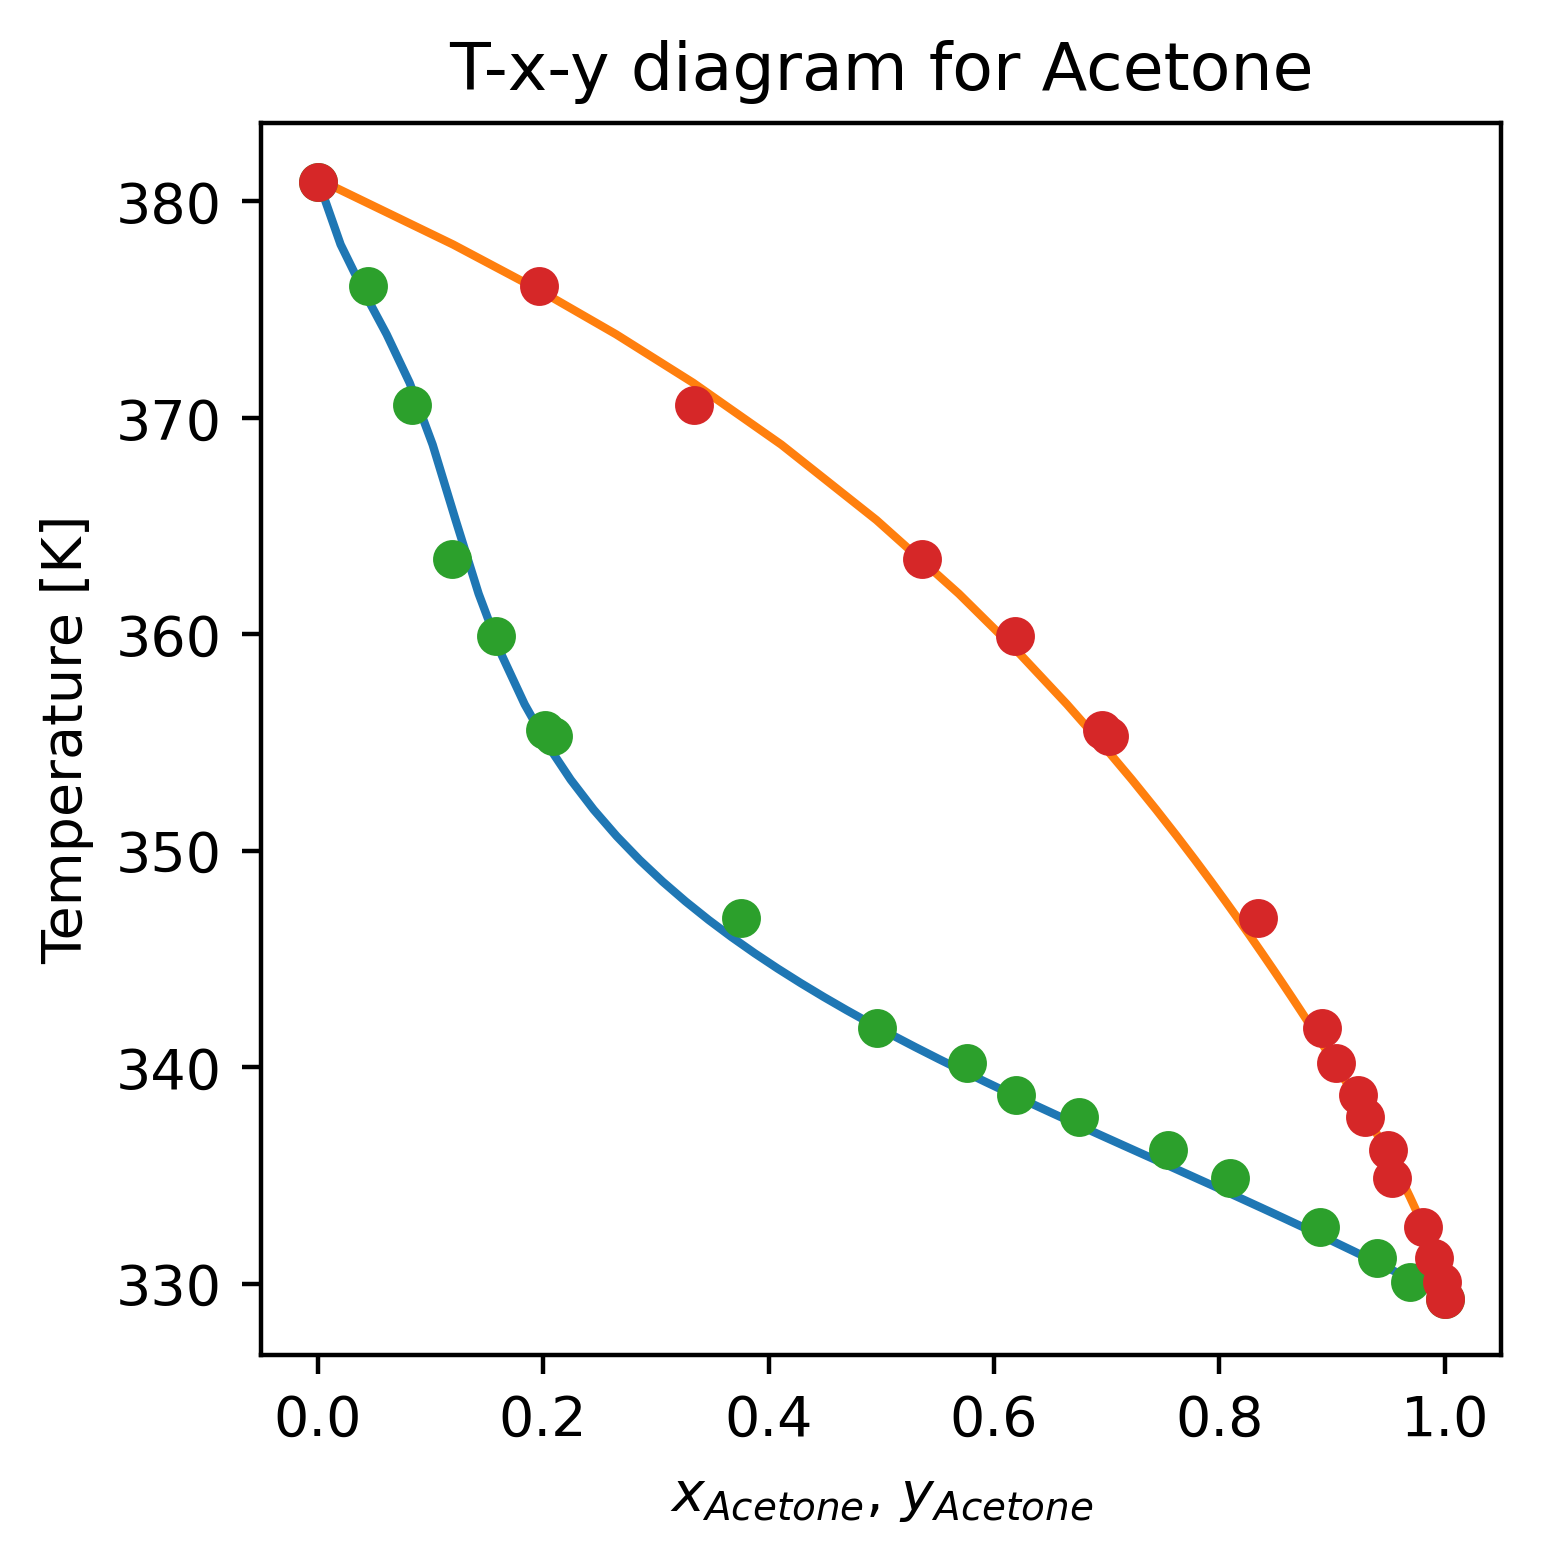

In [18]:
Temperature = np.array(data["T (K)"])
dict1 = {"Temperature [C°]": Temperature, "x1" : x1, "y1" :y1}
df = pd.DataFrame(dict1)
df.set_index("Temperature [C°]",inplace=True)

plt.plot(x_acetone_NRTL,T_soln2)
plt.plot(y_acetone_NRTL,T_soln2)
plt.plot(x1,Temperature,'o')
plt.plot(y1,Temperature,'o')

plt.title('T-x-y diagram for Acetone')
plt.xlabel('$x_{Acetone}$, $y_{Acetone}$')
plt.ylabel('Temperature [K]')

# 3) Make a Txy diagram with all 4 VLE predictions display as lines, and the experimental data displayed as points. Be sure to include axis labels, title, and legend.    

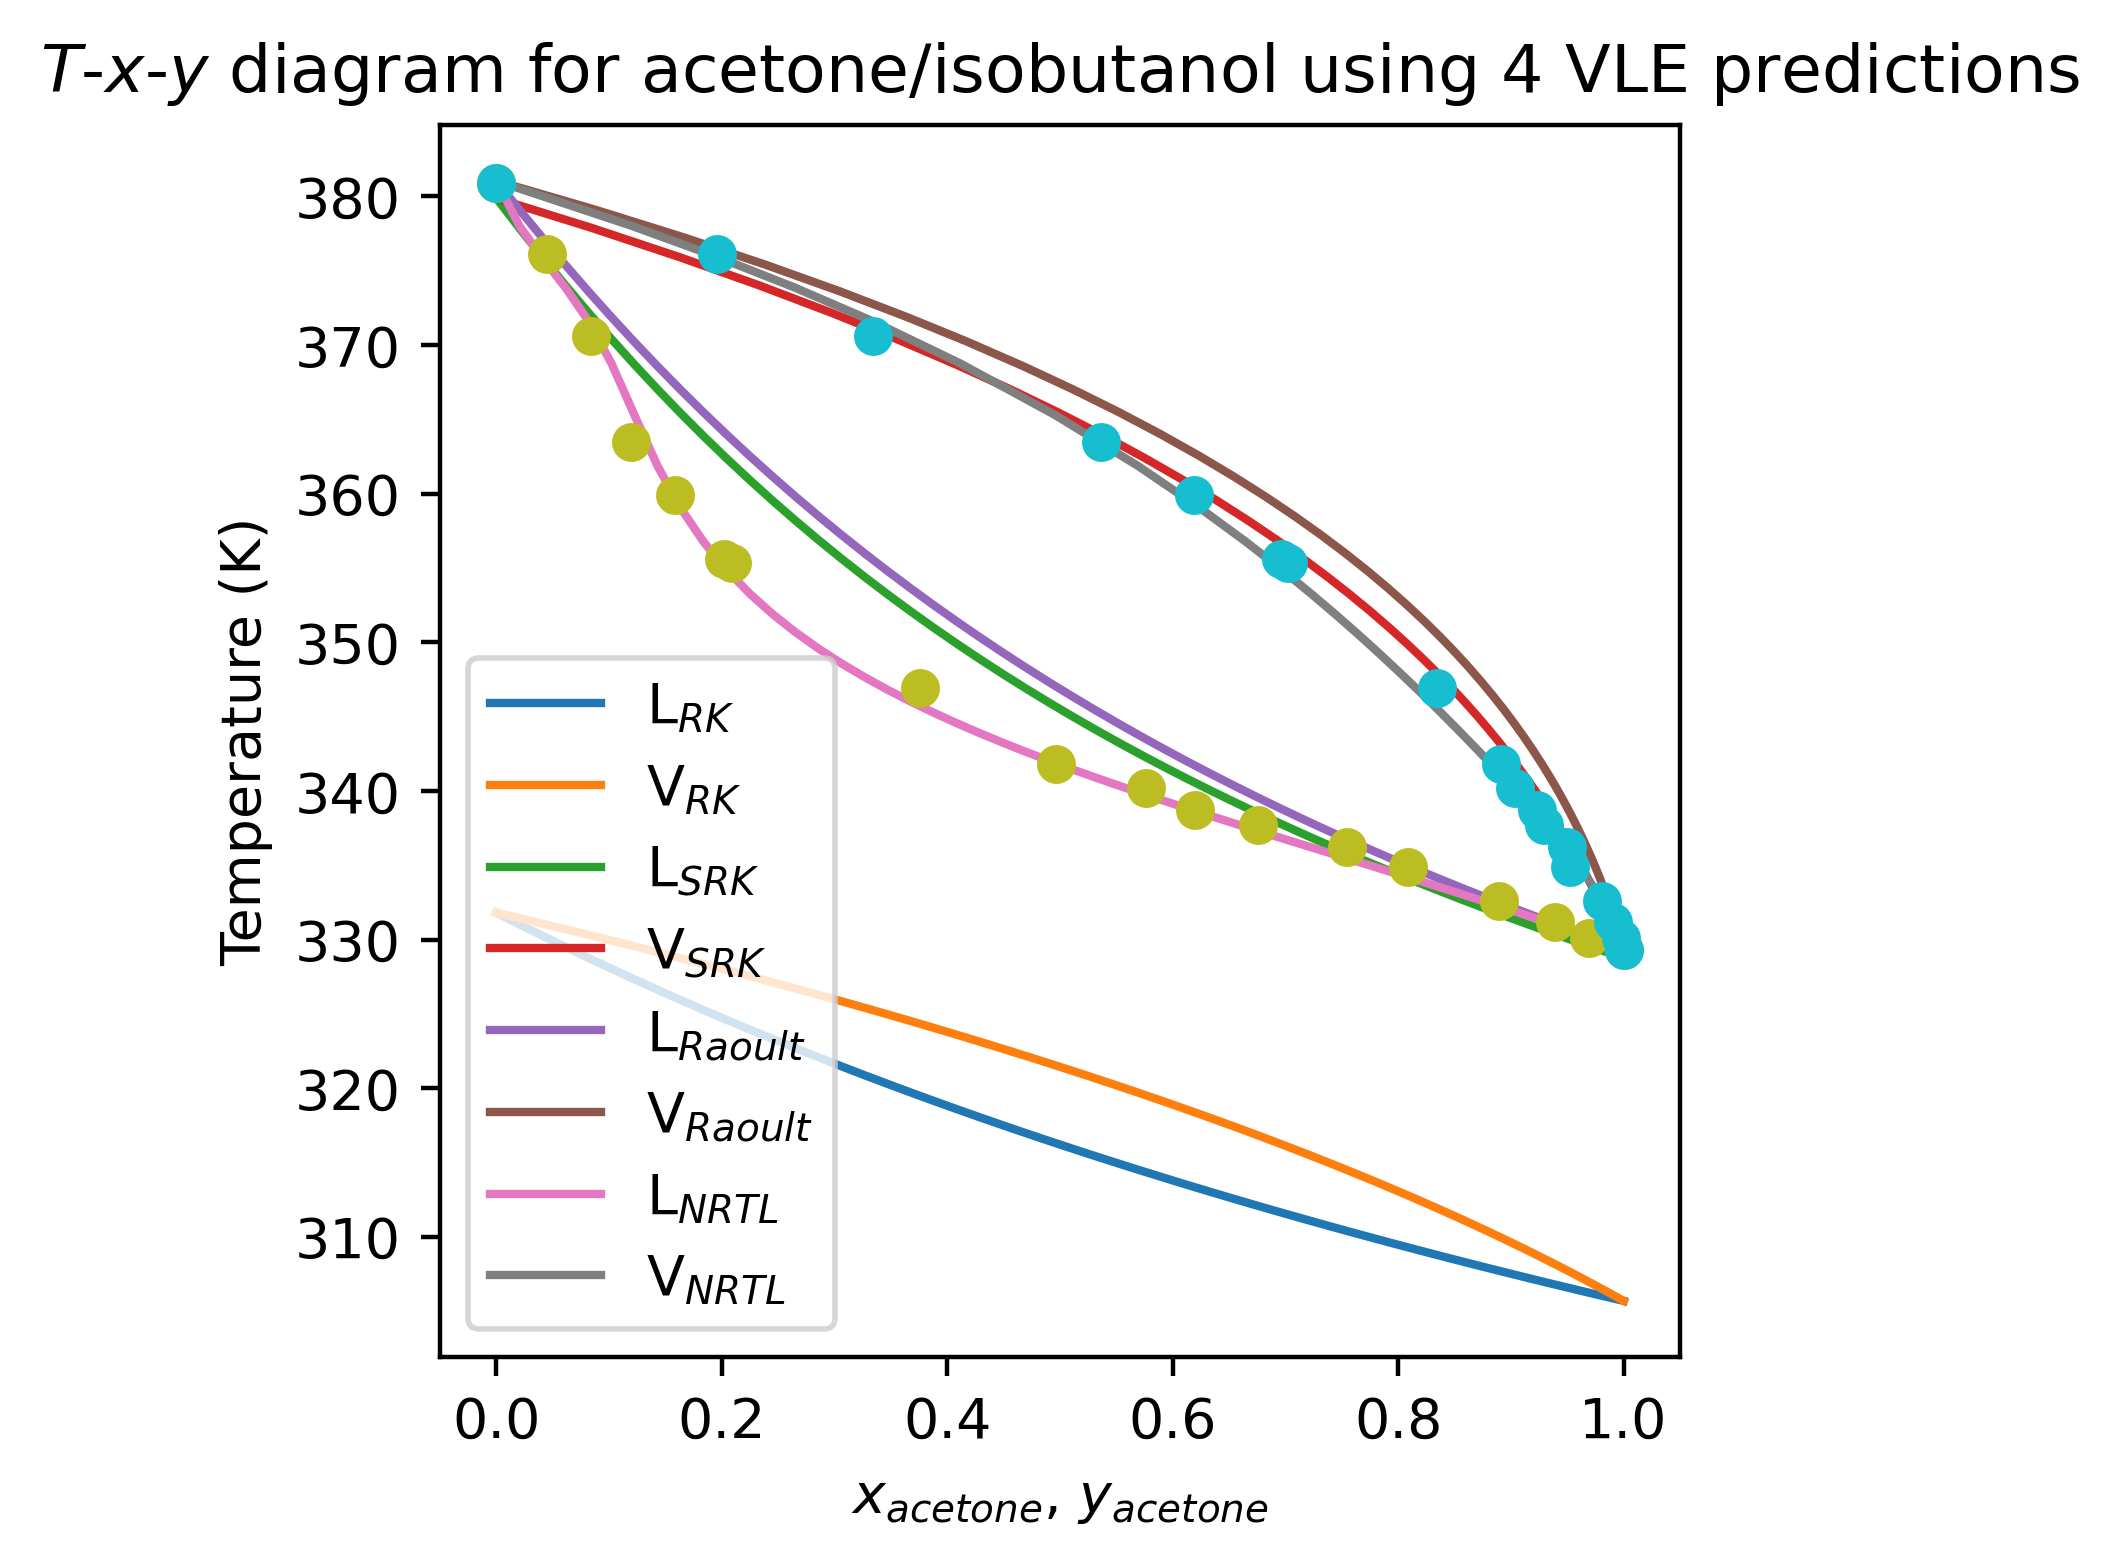

In [19]:
# Plot the T-x-y diagram for Redlich-Kwong EOS:   
plt.plot(x_acetone_RK,T_RK)
plt.plot(y_acetone_RK,T_RK)
plt.plot(x_acetone_SRK,T_SRK)
plt.plot(y_acetone_SRK,T_SRK)
plt.plot(x_acetone_RAO,T_RAO)
plt.plot(y_acetone_RAO,T_RAO)
plt.plot(x_acetone_NRTL,T_soln2)
plt.plot(y_acetone_NRTL,T_soln2)
plt.plot(x1,Temperature,'o')
plt.plot(y1,Temperature,'o')

plt.legend(['L$_{RK}$','V$_{RK}$','L$_{SRK}$','V$_{SRK}$','L$_{Raoult}$','V$_{Raoult}$','L$_{NRTL}$','V$_{NRTL}$'],loc='lower left')
plt.title('$T$-$x$-$y$ diagram for acetone/isobutanol using 4 VLE predictions')
plt.xlabel('$x_{acetone}$, $y_{acetone}$')
plt.ylabel('Temperature (K)')
plt.show()

4) Select the best of these four models and justify your choice. What are the major sources of error in each of the models?
---

Looking at the graph above, the experimental data is graphed out as the dots, and by looking at the curves, it seems like NRTL is the best of the four models. The major sources of error in each of the models are: <br> <br>
NRTL: According to Wikipedia, "These local-composition models are not thermodynamically consistent for a one-fluid model for a real mixture due to the assumption that the local composition around molecule i is independent of the local composition around molecule j." However, in our case, we have a two-liquid model, which is why it seems like NRTL is working great with the least error. <br><br>
Raoult's Law: For Raoult's Law, we all know that it is assumed that the liquids are ideal liquids, which itself is a major source of error, as in reality, many liquids are not ideal. <br><br>
Soave Redlich-Kwong: According to an article, "The major drawback in the SRK EOS is that the critical
compressibility factor takes on the unrealistic universal critical compressibility of 0.333 for all substances. Consequently, the molar volumes are typically overestimated, i.e., densities are underestimated. Another major drawback of the SRK EOS was the poor liquid density prediction." Therefore, these errors may explain why there are some deviations, but this does perform better than the original Redlich-Kwong equation.
(The article link: http://psrcentre.org/images/extraimages/13%20413142.pdf) <br><br>
Redlich-Kwong: According to Wikipedia, "The Redlich–Kwong equation was designed largely to predict the properties of small, non-polar molecules in the vapor phase, which it generally does well." Therefore, the major sources of error in the model would be if the molecules were large or polar. It seems like this is our case, as our molecules are not in the vapor phase, and acetone and isobutanol are relatively polar. This explains why the Redlich-Kwong model does very poorly compared to the other three models.

# Part C: Modeling distillation with McCabe-Thiele

Problem: Your chemical process produces a waste stream of 10 mol/min, consisting of 80 mol% isobutanol and 20 mol% acetone, and will be entering a distillation column with a total condenser and total reboiler as a saturated liquid at 1 atm. You wish to purify this to make anacetone-rich stream with at least 97.5% acetone, and an isobutanol-rich stream with at least 95%isobutanol, using a reflux ratio of 3. 
---

1) Describe the problem setup in markdown text, listing all assumptions involved and your choice of thermodynamic model.
--

Model of choice: I've chosen the NRTL model, since in the previous question, we saw that it had the least amount of error to the experimental data. 

Problem set-up:
$$ F = 10 mol/min $$ 
$$ z_F = 0.2 $$
$$ P = 1 atm $$
$$ x_B = 0.05 $$ 
$$ x_D = 0.975 $$
$$ R = 3 $$ <br>
Assumptions/Given in problem:
Saturated liquid will enter the column (meaning q = 1), total condenser/reboiler used, the P given is constant all around the system, delta H of vaporization is constant for both, and system is insulated (no heat exchange from outside).

2) Write a function called McCabeThiele() that uses your selected thermodynamic model to describe the VLE of the mixture, and takes in the following parameters (in this order): (F, q, zF, xB, xD, RR, P, and additional variables to describe the thermodynamic model)where F is the feed rate, in kmol/hr, q is the q-value of the feed, zF is the mole fraction of acetone in the feed, xB is the mole fraction of acetone in the bottoms, xD is the mole fraction of acetone in the distillate, RR is the reflux ratio, and P is the pressure.
---

In [20]:
# First define the objective function we want to solve for to get the best fit equation:
def objective(x, a, b, c, d, e, f): 
    return a*x + b*x**2 + c*x**3 + d*x**4 + e*x**5 + f



In [21]:
# We need to find out the intersection/convergence between the VLE solved by x_NRTL and y_NRTL, q-line, and the 
# rectifying operating line. Let's create a function that can do this for us. Variables are q, zF, xD, RR, and the NRTL
# values, as the NRTL values will affect the VLE, and the value q and zF will affect the q-line (depending on the
# q-line, the intersection will change). Finally, xD and RR will define the operating line that we would 
# need to draw.

def converge(q, zF, xD, RR, x_acetone_NRTL, y_acetone_NRTL):
    
    # First, do a curve_fit using the objective function for the VLE, giving the best fit curve for the VLE:
    params, _ = curve_fit(objective, x_acetone_NRTL, y_acetone_NRTL)
    a,b,c,d,e,f = params #store the parameters for the best fit curve in a,b,c,d,e,f

    # Use sympy to solve best fit curve and operating line together:
    sym.var('x,y')

    # Eq_1 = best fit curve, Eq_2 = q_line
    Eq_1 = sym.Eq(y, a*x + b*x**2 + c*x**3 + d*x**4 + e*x**5 + f)

    # However, for Eq_2, we can have q = 1, q = 0, or q = any other value between 0 and 1, so three cases:
    if (q == 1): # if q = 1
        Eq_2 = sym.Eq(zF, x)
    elif (q == 0): # if q = 0
        Eq_2 = sym.Eq(zF, y)
    else: # if q != 0 or 1, then it must be any value between 0 and 1:
        Eq_2 = sym.Eq(q/(q - 1)*x,y)
    
    # Then solve the two equations:
    result_1 = sym.solve([Eq_1,Eq_2],(x,y))

    # Now we use sympy again to solve the operating line and q-line together (like above): 
    sym.var('v,w')

    # Eq_3 = operating line, Eq_2 = same as above.
    Eq_3 = sym.Eq((RR/(RR + 1))*v + xD/(RR + 1),w)

    # However, for Eq_2, we can have q = 1, q = 0, or q = any other value between 0 and 1, so three cases:
    if (q == 1): # if q = 1
        Eq_2 = sym.Eq(zF, v)
    elif (q == 0): # if q = 0
        Eq_2 = sym.Eq(zF, w)
    else: # if q != 0 or 1, then it must be any value between 0 and 1:
        Eq_2 = sym.Eq(q/(q - 1)*v,w)
    
    # Then solve the two equations:
    result_2 = sym.solve([Eq_3, Eq_2], (v, w))

    # Now we have solved for the intersection/convergence, let's return the result:
    return [result_1[0][0], result_1[0][1], result_2[v], result_2[w]]

    # result_1[0][0], result_1[0][1] will hold the (x,y) solution for the Eq 1 and 2, which is the VLE best-fit curve
    # and q-line. 
    # result_2[v], result_2[w] will hold the (x,y) solution for the Eq 2, and 3, which is the rectifying operating line
    # and q-line. 

In [22]:
# Now let's define the McCabeThiele function. Note it inputs x and y from the NRTL from previous question:
def McCabeThiele(F, q, zF, xB, xD, RR, P, x_acetone_NRTL, y_acetone_NRTL):
    # First calculate bottom & distillate molar flow rates: 
    D_flowrate = F*(zF - xB)/(xD - xB)
    B_flowrate = F - D_flowrate
    
    # Then do a curve_fit using the objective function for the VLE, giving the best fit curve for the VLE:
    params, _ = curve_fit(objective, x_acetone_NRTL, y_acetone_NRTL)
    a,b,c,d,e,f = params #store the parameters for the best fit curve in a,b,c,d,e,f
    
    # Used to draw y=x line:
    yxline = np.linspace(0,1)
    
    # Now we want to draw the y-x line, the VLE, q-line, rectifying operation line, and stripping operation line:
    # We've already solved the parameters in the converge function to plot these: 
    
    # Draw the y-x line:
    plt.plot(yxline, yxline, linestyle = '-', color = 'black')
    
    # Then draw the VLE gotten from the NRTL in previous question:
    plt.plot(x_acetone_NRTL, y_acetone_NRTL, linestyle = '-', color = 'blue') 
    
    # To draw the q-line, use converge function to find the solutions:
    q_line_x, q_line_y, op_line_x, op_line_y = converge(q, zF, xD, RR, x_acetone_NRTL, y_acetone_NRTL)
    
    # Draw the q-line:
    plt.plot([q_line_x, zF], [q_line_y, zF], linestyle = '-', color = 'purple')
    
    # Draw the rectifying operating line:
    plt.plot([0,xD], [xD/(RR + 1),xD], linestyle = '-', color = 'red')
    
    # Draw the stripping operatig line:
    plt.plot([op_line_x,xB], [op_line_y,xB], linestyle = '-', color = 'green')
    
    # We are now ready to calculate for the number of stages. Before that,
    # Now let's initialize some variables that we will use the stage calculation:
    
    x_0 = xD # We start drawing at xD
    y_0 = xD # We start drawing at xD
    x_1 = xD # Dummy variable (used later)
    y_1 = xD # Dummy variable (used later)
    num_rect = 0 # Rectifying line stage counter
    num_strip = 0 # Stripping line stage counter
    feed_position = 0 # Ideal feed location, which is num_rect + 1. 
    
    # We begin the "stepping down" here:
    while (x_0 > xB): # We want to only repeat the vertical/horizontal line "stepping down" while x_0 > xB
        # We then draw the horizontal line, and to know when to end the horizontal line, we use sympy:
        sym.var('x')
        # solve the a,b,c,d,e,f coefficients here:
        result = sym.solve(a*x + b*x**2 + c*x**3 + d*x**4 + e*x**5 + f - y_0, x) 
        x_1 = result[0] # Dummy variable x_1 holds where we have to stop the horizontal line. 
        # Draw the horizontal line:
        plt.plot([x_1,x_0],[y_1,y_0],color = 'yellow') 
        x_0 = x_1 # Store this dummy value as x_0
        y_0 = y_1 # Store this dummy value as y_0
        
        # Now we want to draw the vertical lines, but we need to divide it up to 
        # If we are drawing until the rectifying or stripping operating line:
        
        if (x_1 >= zF): # We want to draw the rectifying operating line if x_1 >= zF
            y_1 = (RR/(RR + 1))*x_0 + xD/(RR+1) # Find where to end drawing up to rectifying line
            num_rect = num_rect + 1 # Add one stage to rectifying line number counter
        
        else: # We want to switch to drawing the stripping operating line if x_1 < zF
            # Find where to end stripping line
            y_1 = ((op_line_y - xB)/(op_line_x - xB))*(x_1 - xB) + xB 
            num_strip = num_strip + 1 # add one stage to stripping line number counter
            
            # We know ideal feed location is right when the transition is made to the stripping operating
            # line:
            feed_position = num_rect + 1
            
        # Now we need to plot the vertical lines, whether it be rectifying or stripping operating line:
        if (x_0 > xB): # We want to draw the operating lines only if x_0 > xB
            plt.plot([x_1, x_0], [y_1, y_0], color = 'blue') # Plot line to the operating line
        else: # If x_0 not > xB, that means we are done now and we want to draw the last line:
            plt.plot([x_1, x_0], [x_1, y_0], color = 'blue') 
            
        x_0 = x_1 # Store this dummy value as x_0
        y_0 = y_1 # Store this dummy value as y_0
        
    # Number of total stages is the number of rectifying and stripping line added together:
    num_stages = num_rect + num_strip
    # Now that we have done plotting the steps and calculating feed stage, number of stages, and D and B flow rates,
    # let's show the results:
    
    # Add a legend:
    plt.legend(['y = x line','NRTL Equilibrium curve (VLE)', 'q-line', 'Rectifying operating line', 'Stripping operating line'], fontsize = 8)
    
    # Add labels and a title:
    plt.title('McCabe-Thiele Method for Acetone-Isobutanol System ')
    plt.xlabel('$x_{Acetone}$')
    plt.ylabel('$y_{Acetone}$')

    # Now, print the final results that we want:
    
    print("The ideal feed location is at stage number ", feed_position)
    print("The total number of stages needed is ", num_stages)
    print("Flow rate of B is ", B_flowrate, " mol/min")
    print("Flow rate of D is ", D_flowrate, " mol/min")

    # We also want to return the variables so that we can use this function:
    return [feed_position, num_stages, B_flowrate, D_flowrate]
    

The ideal feed location is at stage number  3
The total number of stages needed is  5
Flow rate of B is  8.378378378378379  mol/min
Flow rate of D is  1.621621621621622  mol/min


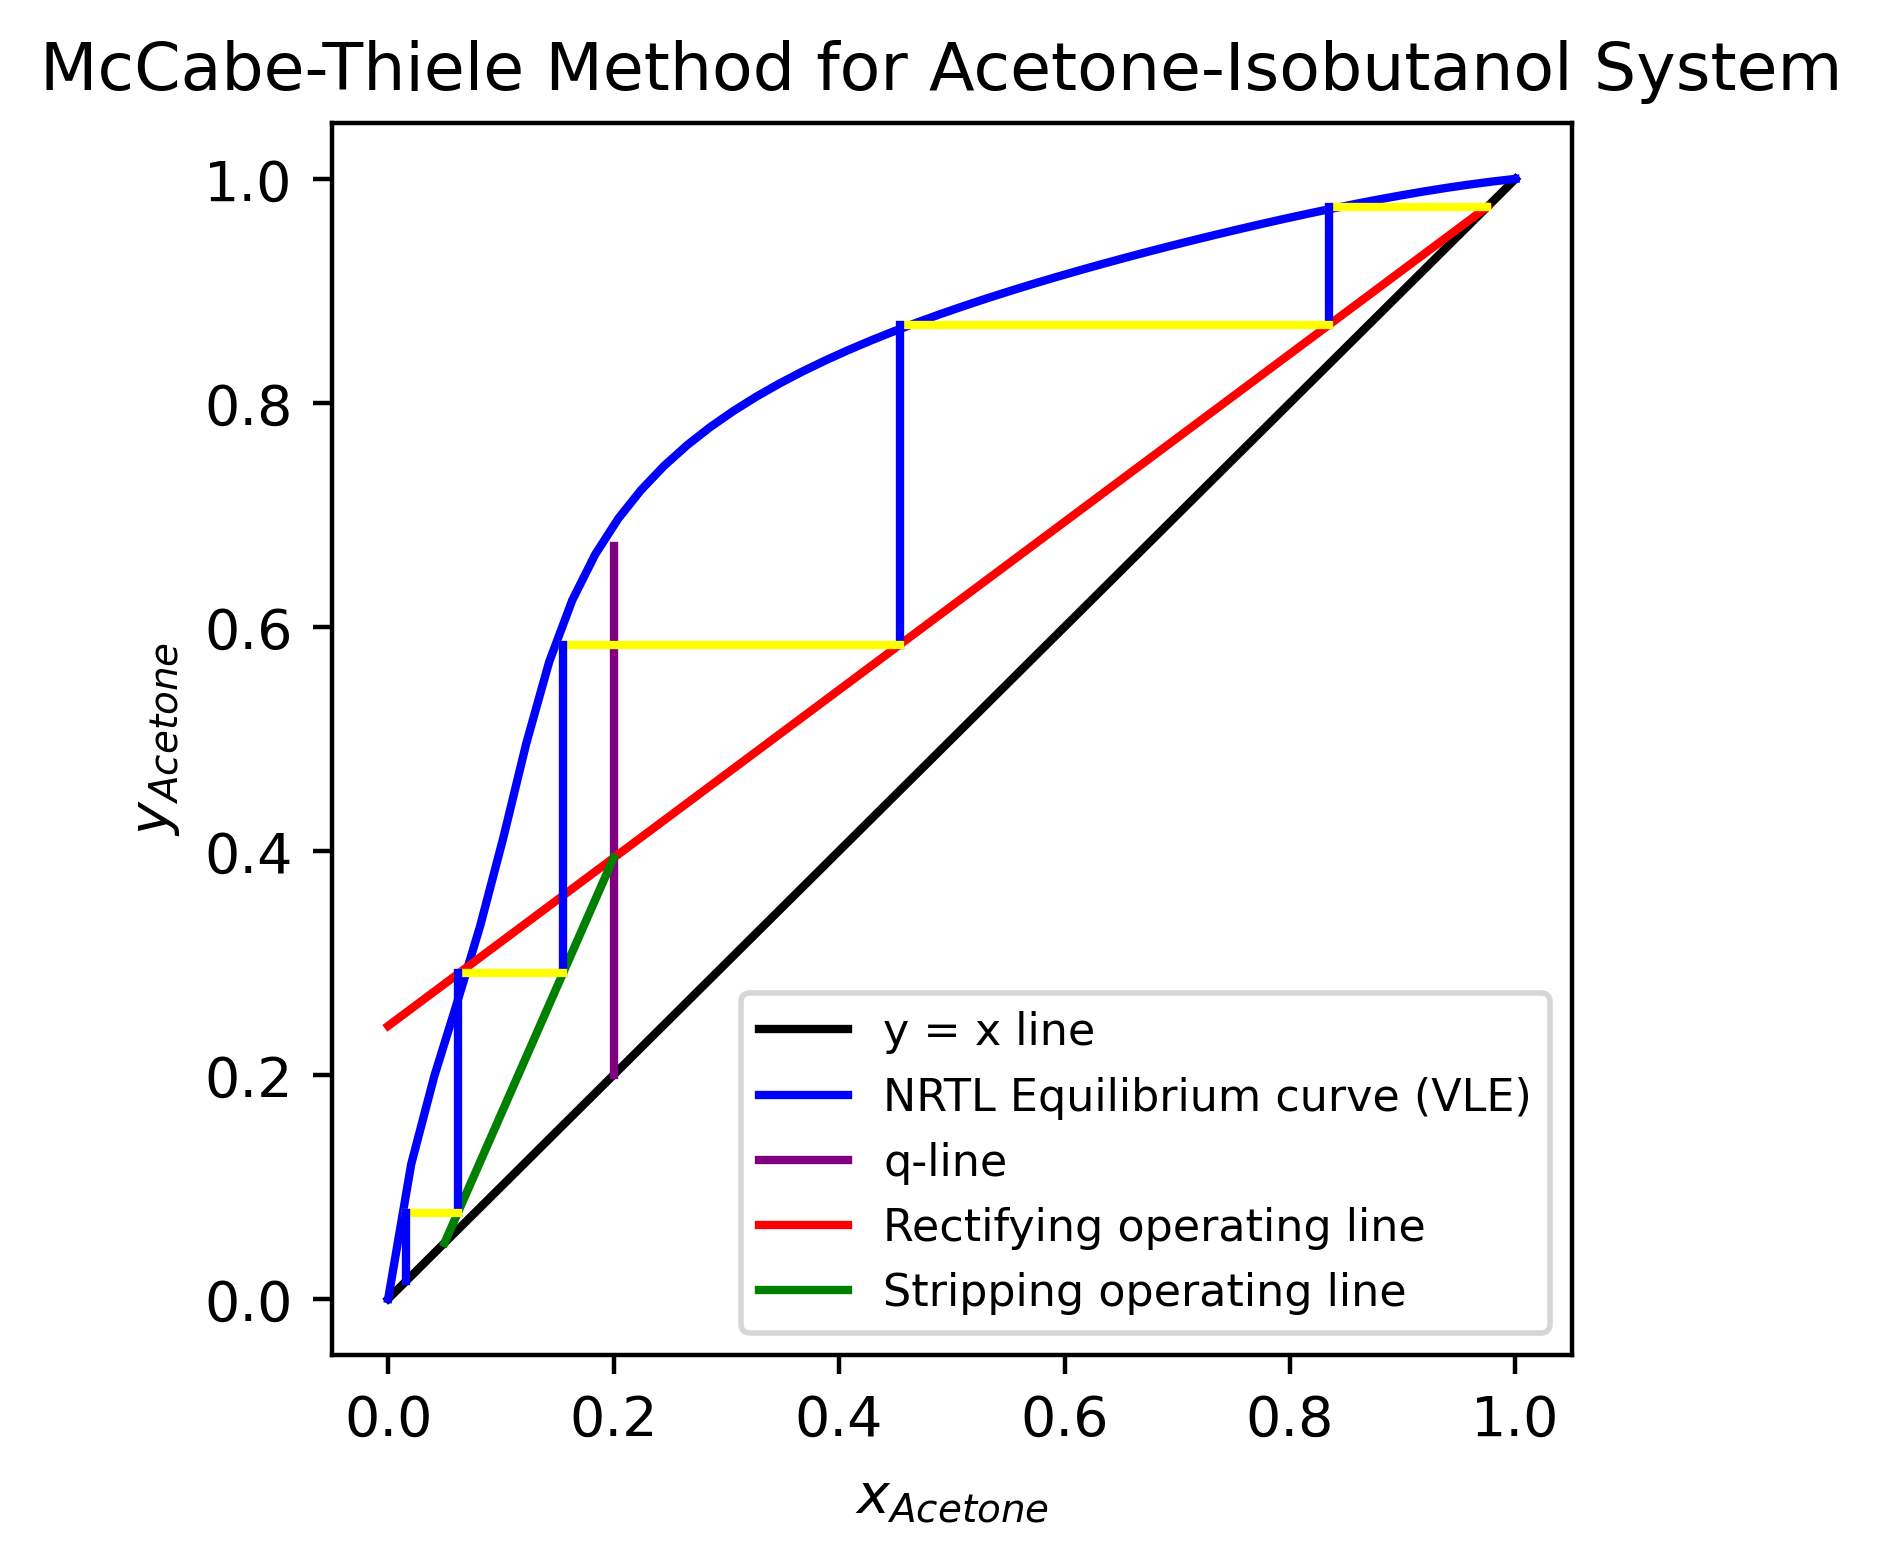

In [23]:
# Now we want to find the solution for this specific problem:
# Input is in the form:
# McCabeThiele(F, q, zF, xB, xD, RR, P, x_acetone_NRTL, y_acetone_NRTL):
# Feed given in 10 mol/min, q = 1, zF = 0.2, xB = 0.05, xD = 0.975, RR = 3, P = 1 atm
# And then we can use x_acetone_NRTL and y_acetone_NRTL from previous question:
solution = McCabeThiele(10, 1, 0.2, 0.05, 0.975, 3, 1, x_acetone_NRTL, y_acetone_NRTL)

So, the final answers are: <br> The ideal feed location is at stage number: 3 <br>The total number of stages needed is:  5 <br>Flow rate of B is:  8.378378378378379  mol/min <br> Flow rate of D is:  1.621621621621622  mol/min
---

3) Modify the column(x, t) code for the 32-stage distillation column provided in class to create a time-dependent model of your distillation column. (15 points) This will be similar to the scipy implementation provided in class, but you will also need to <br>
---
a) Replace the yfx function with something that doesn’t assume that alpha is a constant value. You’ll need to invoke your thermodynamic model. <br>
---
b) Use variables to change the size of the column and the feed tray location. <br>
---
c) Assume the molar holdup in all stages is 0.5 moles
---

In [24]:
# Step 0 - We need to define RR, F, D, L, V, Lbar, and B 
# Reflux ratio:
RR = 3
# Feed's flow rate:
F = 10
# Distillate's flow rate: (Gotten from above McCabe-Thiele function)
D = solution[3]

# Rectification section's liquid flow rate: (This comes from the definition of the reflux ratio)
L = RR * D

# Column's vapor flow rate (This comes from the overall mole balance on the condenser)
V = L + D

# Stripping section's liquid flow rate: (This comes from an overall mole balance on the feed stage)
Lbar = F + L

# Bottom's flow rate (this comes from the overall mole balance on the reboiler)
#B = Lbar - V


In [25]:
#### Step 1 - define our constants 
# We already defined F, D, L, V, Lbar, and B 
# feed composition
zF = 0.2

# total molar holdup on each tray (moles) (assumed to be 0.5)
atray = 0.5

# total molar holdup in condenser (moles) (assumed to be 0.5)
acond = 0.5

# total molar holdup in reboiler (moles) (assumed to be 0.5)
areb = 0.5

Tguess = 355 #K

# Define the yfx function: (note it doesn't take in alpha as a variable)
# Ultimately, we want to return y, but we first need to solve for T using the NRTL thermodynamic model that we used.
def yfx(x):
    if np.size(x) == 1:
        z = np.array([x, 1 - x])
        # use NRTL thermodynamic model to calculate T
        T = fsolve(resfunNRTL, Tguess, args = (P_bar, AntoineCoeffs, z, parameters)) 
        # Then calculate y using modified Raoult's Law and using the calculated T from above:
        y = modified_raoult_kvalue(T, P_bar, AntoineCoeffs, z, parameters)*z
        ra = [y[0],x,1-y[0],1-x]
        # calculate alpha!
        alpha = (ra[0]/ra[1])/(ra[2]/ra[3])
        return x*alpha/(1+(alpha-1)*x)
    else: 
        for i in x:
            for j in i: 
                z = np.array([j,1-j])
                T = fsolve(resfunNRTL, Tguess, args = (P, AntoineCoeffs, z, parameters)) 
                y = modified_raoult_kvalue(T, P, AntoineCoeffs, z, parameters)*z
                ra = [y[0],j,1-y[0],1-j]
                alpha = (ra[0]/ra[1])/(ra[2]/ra[3])
                return j*alpha/(1+(alpha-1)*j)

In [26]:
#### step 2 - define a function which calculates the derivative
# basically, we need to take out alpha from distillationscipy notebook we were given:

xB = 0.05
xD = 0.975
def column(x, t):
    # Initialize a variable for dxdt for all stages (so zeros for number of stages)
    num_stages = solution[1] #number of stages
    dxdt = np.zeros(num_stages)
    
    ### Condenser
    #dxdt[0] = (V*yfx(x[1]) - D*yfx(x[0]) - L*x[0])/acond
    dxdt[0] = (L*(xD-x[0])- V*(yfx(x[0]) - yfx(x[1])))/ acond

    ### Rectifying section
    for i in range(1, solution[0] - 1):
        dxdt[i] = (L*(x[i - 1] - x[i]) - V*(yfx(x[i]) - yfx(x[i + 1])))/atray

    ### Feed tray
    feed = solution[0] - 1 # feed stage
    dxdt[feed] = (F*zF + L*x[feed - 1] - Lbar*x[feed] - V*(yfx(x[feed])) - yfx(x[feed + 1]))/atray
    
    ### Stripping section
    for i in range(feed + 1, num_stages - 1):
        dxdt[i] = (Lbar*(x[i - 1] - x[i]) - V *(yfx(x[i]) - yfx(x[i + 1])))/atray
    
    ### Reboiler
    #dxdt[num_stages - 1] = (Lbar*x[num_stages - 2] - B*x[num_stages - 1] - V*yfx(x[num_stages - 1]))/areb
    dxdt[num_stages - 1] = (Lbar*x[num_stages - 2] - x[num_stages - 1] - V*(yfx(x[num_stages - 1])-xB))/areb
    return dxdt

4) Assume the column is initialized with 20% acetone, and simulate the column. Plot the composition in each tray as a function of time. Adjust the array for the time intervals until you see the compositions reach equilibrium. About how long does it take to reach equilibrium? 
---

In [27]:
#### Step 3 - define a time interval for the solver to evaluate the differential equation
ts = np.linspace(0, 10, 25000) # Defines a numpy array with 75 time points, evenly spaced over 25 time units

#### Step 4 - specify our initial values

# We need num_stages of initial values, one for each stage in the column
# We're starting with a column that initially has every stage filled with liquid with x = 0.2
num_stages = solution[1]
x0 = np.ones(num_stages)*0.2 #20% acetone

#### Step 5 - integrate the equation numerically
# odeint takes the function, the initial conditions, and the time steps, and returns the result in a numpy array
xs = odeint(column, x0, ts)

#### Step 6 - collect results and plot

# First, let's just look at what xs contains:

print(xs.shape)
print(xs)
# Each row is a point in time, and each column is a different tray


(25000, 5)
[[0.2        0.2        0.2        0.2        0.2       ]
 [0.20299925 0.19999013 0.19590259 0.19997158 0.19889752]
 [0.20596489 0.19996007 0.19188546 0.19988755 0.19780365]
 ...
 [0.50036343 0.13055727 0.05649183 0.03440065 0.02159814]
 [0.50036343 0.13055727 0.05649183 0.03440065 0.02159814]
 [0.50036343 0.13055727 0.05649183 0.03440065 0.02159814]]


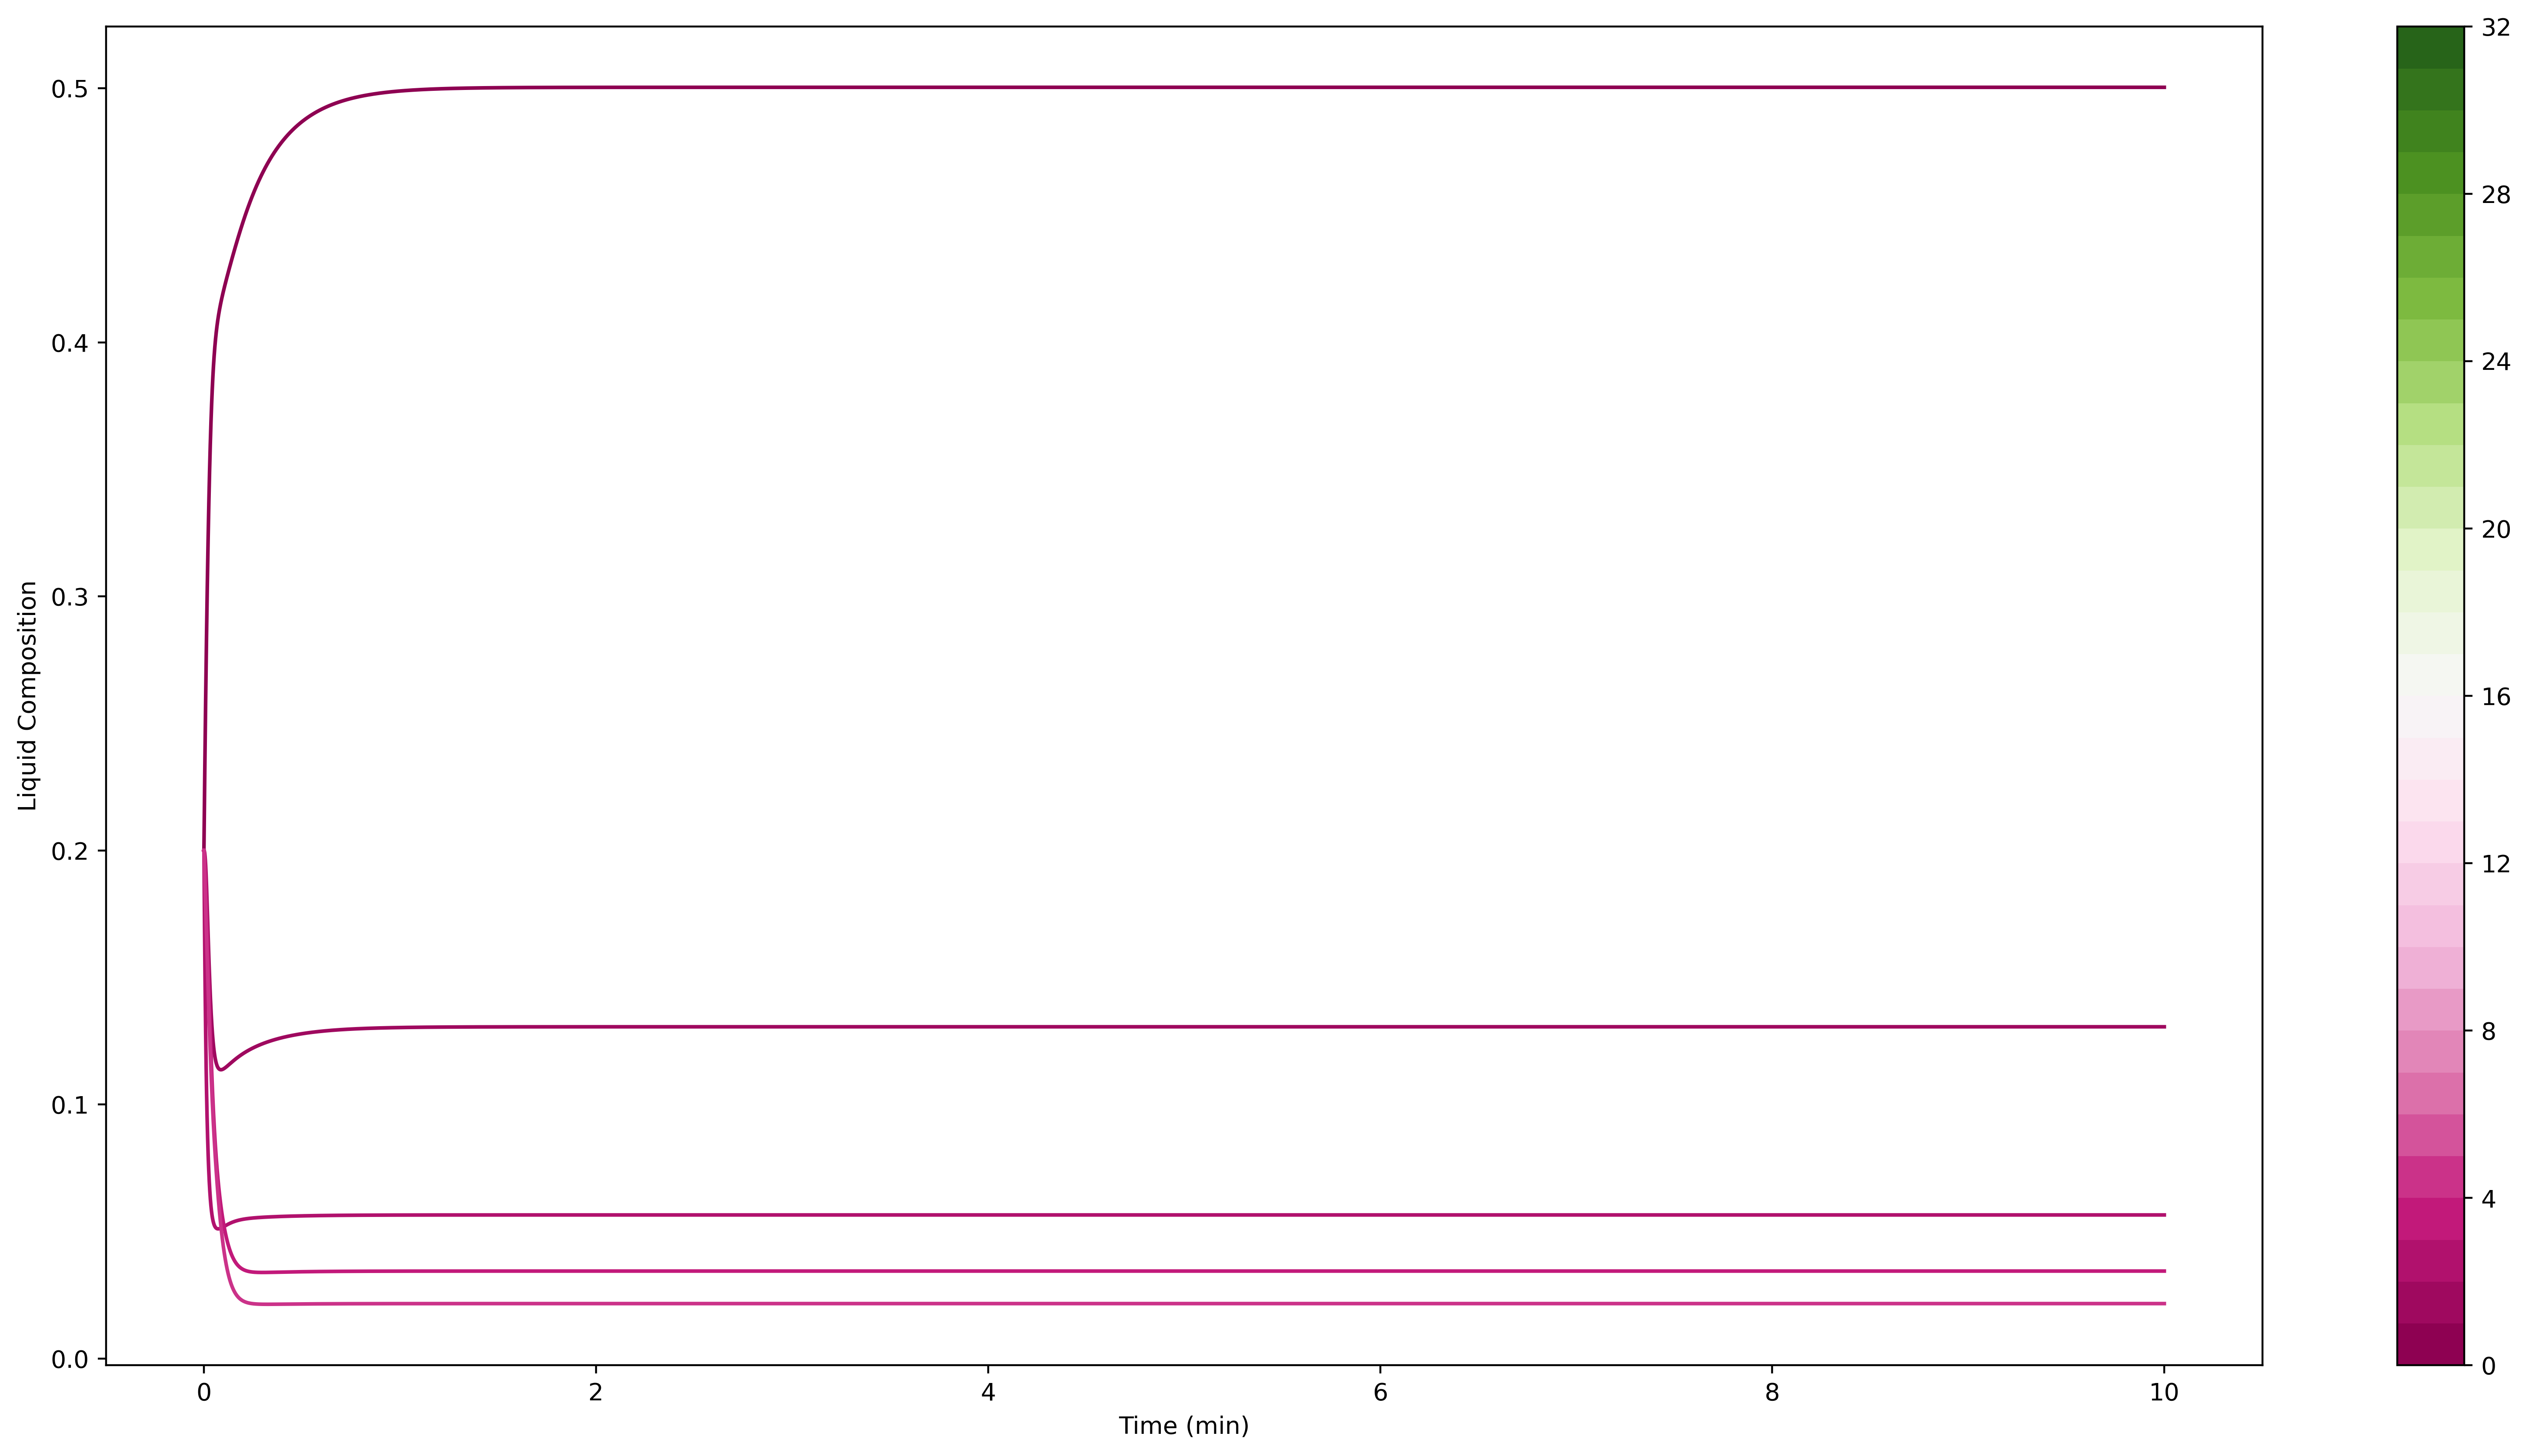

In [28]:
## plot the composition over time in different trays

# we're going to use a colormap to make the visualization look nice

cmap = plt.cm.PiYG
norm = matplotlib.colors.BoundaryNorm(range(0, 33), cmap.N)

fig = plt.figure(figsize = (20, 10))
ax = fig.add_subplot()

for i in range(0, solution[1]):
    ax.plot(ts, xs[:, i], color = cmap(norm(i)))

# label axes
ax.set_xlabel('Time (min)')
ax.set_ylabel('Liquid Composition')

fig.colorbar(plt.cm.ScalarMappable(norm = norm, cmap = cmap), ax = ax)

# create a second axes for the colorbar
plt.show()

After hours and hours of trying to debug this code, I still could not find why the curve is looking like this, the liquid composition doesn't look right, but at least we can see when it will reach equilibrium.

As seen in the plot above, we can see that equilibrium is all reached at around 1 minute. 
---

Extra credit: How important is it to have accurate thermodynamic models? What effect will this have on thedesign and performance of a distillation column? To address this question, perform the following additional tasks:
---

1) Select the 2nd-best thermodynamic model for the mixture
----

The 2nd-best thermodynamic model for the mixture seems to be the SRK model. 

2) Using the same design specifications given in Part C, solve for the number of trays and the optimal feed stage according to the different thermodynamic model. This is “column design 2,” and it was designed using less accurate thermodynamics. 
---

The ideal feed location is at stage number  4
The total number of stages needed is  6
Flow rate of B is  8.378378378378379  mol/min
Flow rate of D is  1.621621621621622  mol/min


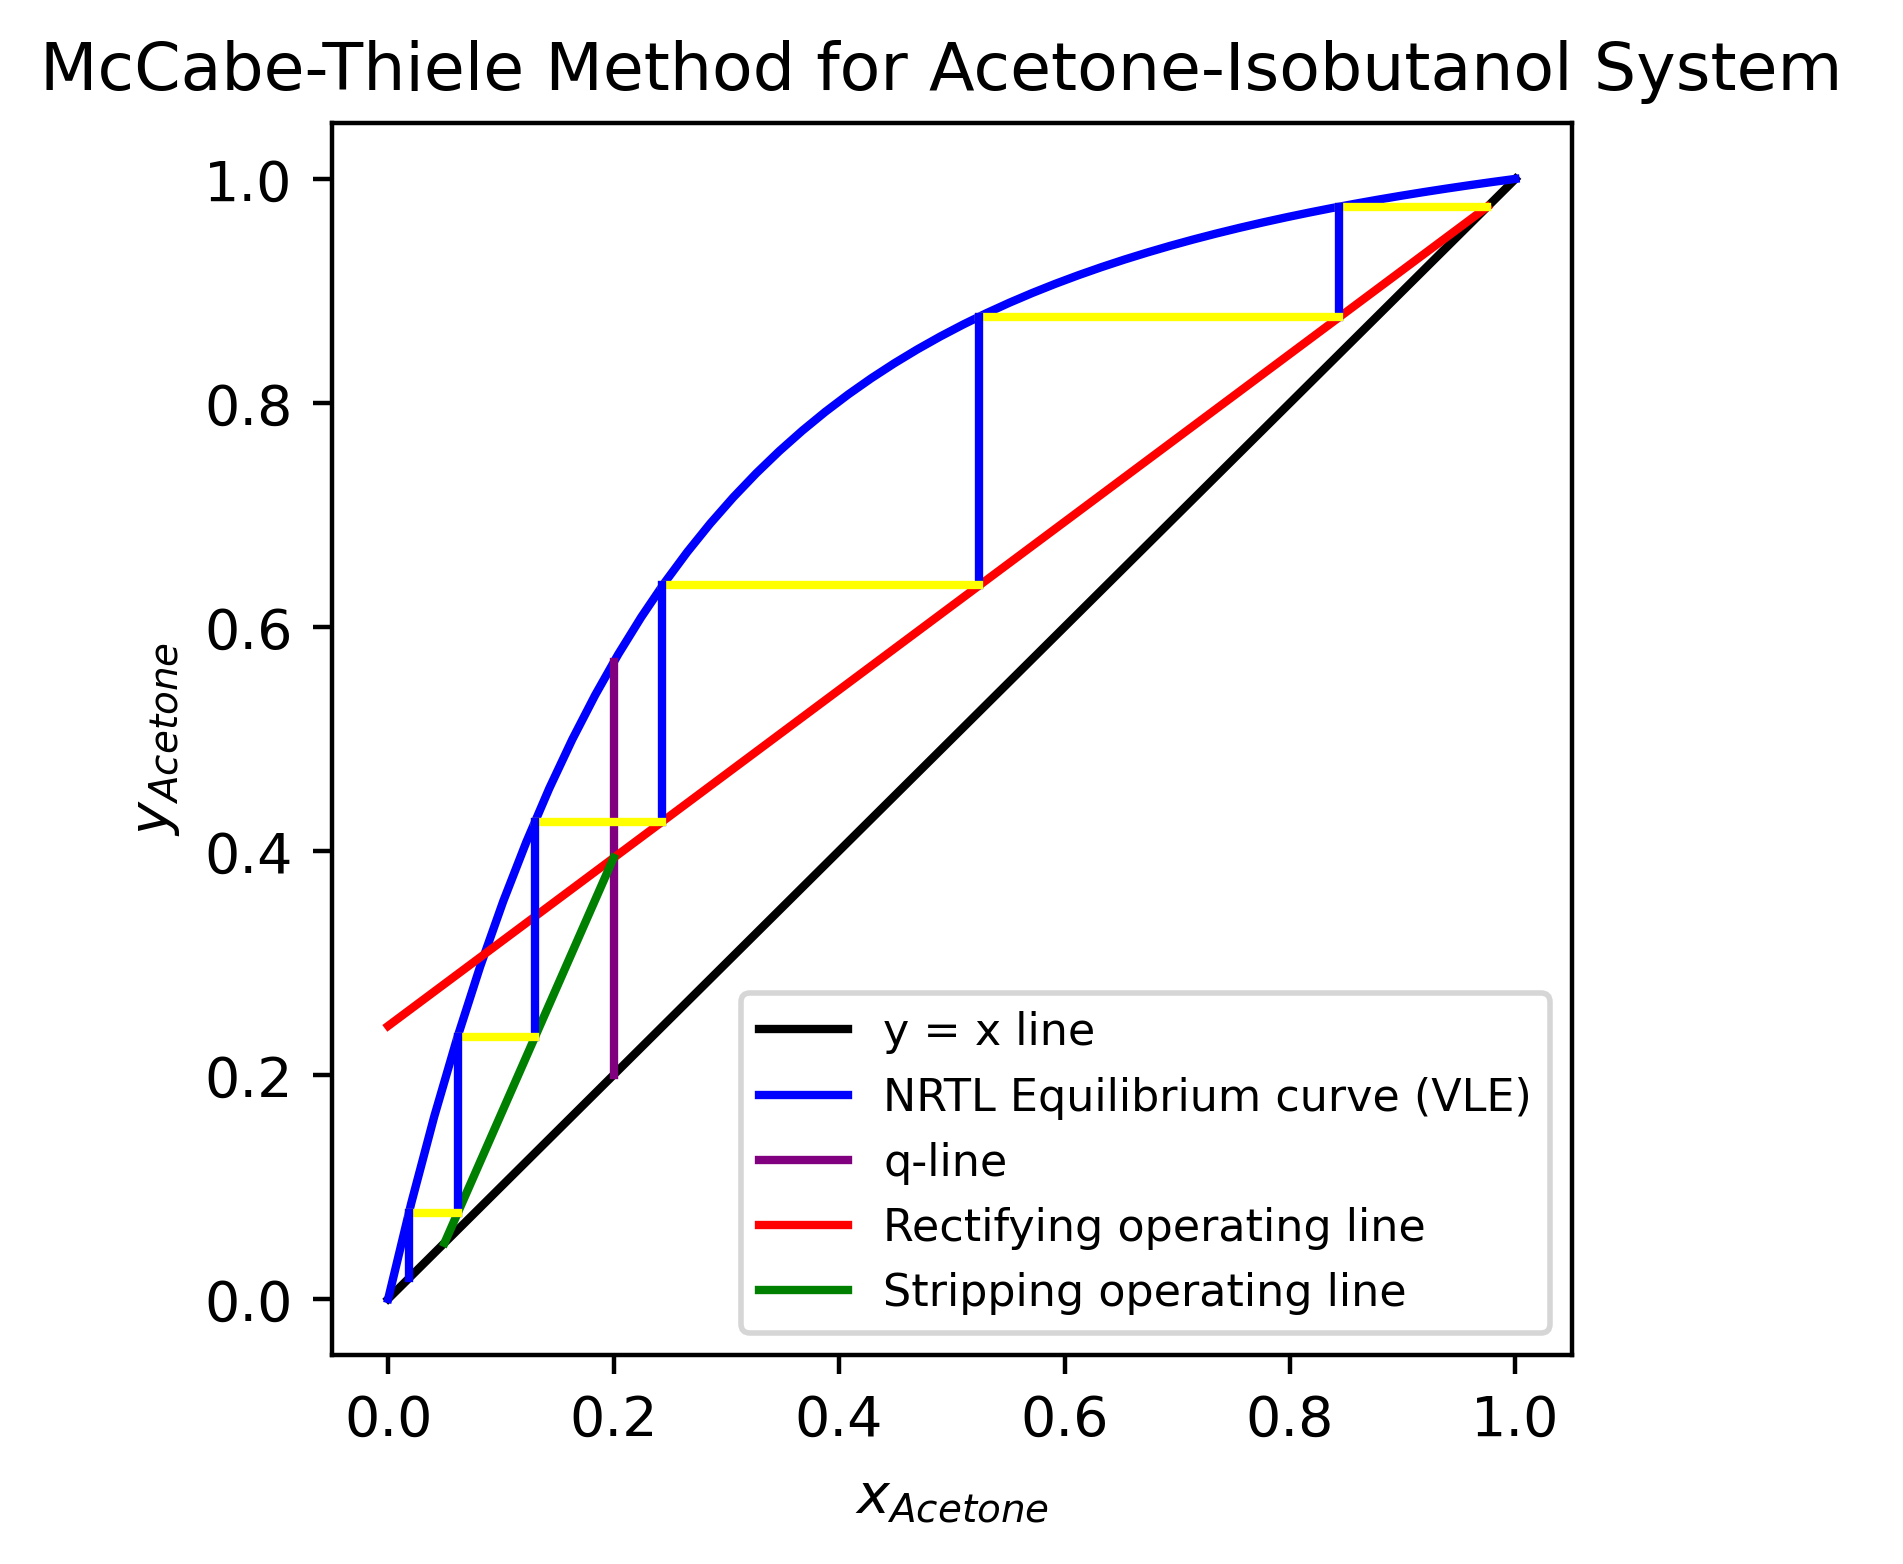

In [29]:
solution = McCabeThiele(10, 1, 0.2, 0.05, 0.975, 3, 1, x_acetone_SRK, y_acetone_SRK)

3) Set up the ODE simulation for “column design 2,” but use the more accurate thermodynamic model. This is akin to having the “real” fluid flowing through a column designed using inaccurate thermodynamic data. 
---

We just run the same ODE simulation code we did for part c): 

(25000, 6)
[[0.2        0.2        0.2        0.2        0.2        0.2       ]
 [0.20299929 0.20000578 0.19998431 0.19590258 0.19997158 0.19889752]
 [0.2059652  0.20002282 0.199937   0.1918854  0.19988755 0.19780365]
 ...
 [0.56510566 0.15241567 0.06813258 0.04848815 0.02956807 0.01921759]
 [0.56510566 0.15241567 0.06813258 0.04848815 0.02956807 0.01921759]
 [0.56510566 0.15241567 0.06813258 0.04848815 0.02956807 0.01921759]]


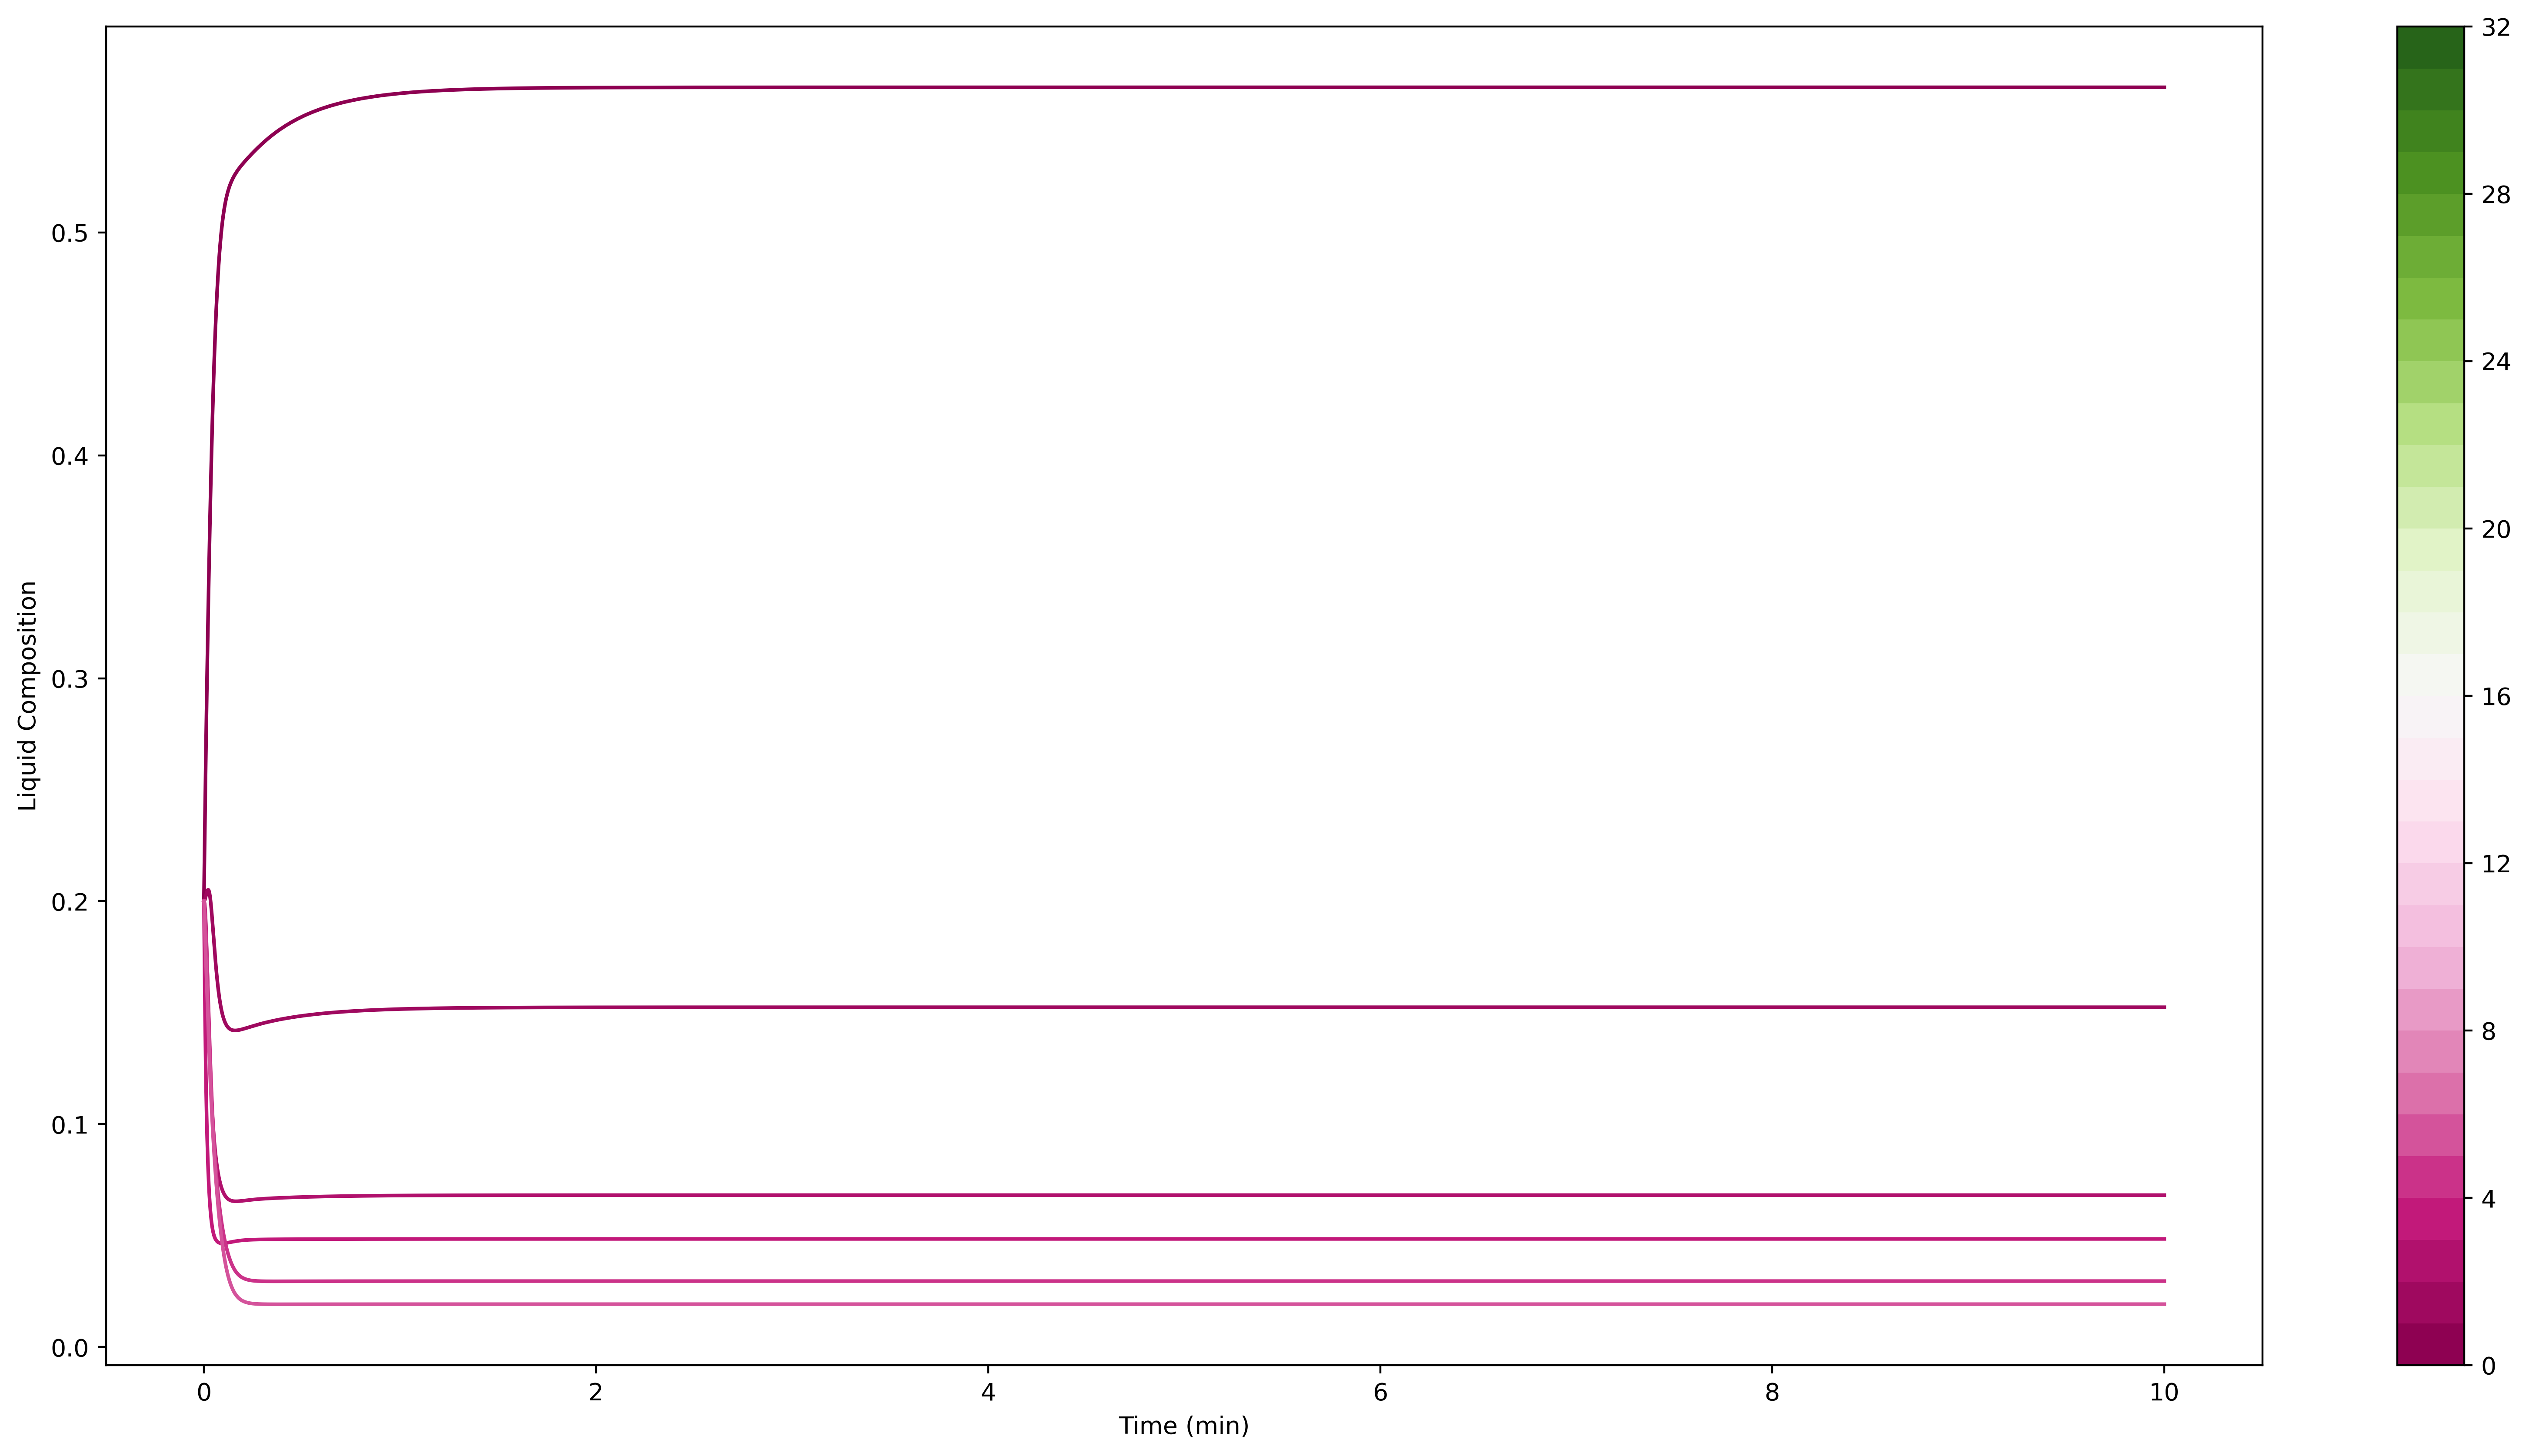

In [30]:
#### Step 1 - define our constants 
# We already defined F, D, L, V, Lbar, and B 
# feed composition
zF = 0.2

# total molar holdup on each tray (moles) (assumed to be 0.5)
atray = 0.5

# total molar holdup in condenser (moles) (assumed to be 0.5)
acond = 0.5

# total molar holdup in reboiler (moles) (assumed to be 0.5)
areb = 0.5

Tguess = 355 #K

# Define the yfx function: (note it doesn't take in alpha as a variable)
# Ultimately, we want to return y, but we first need to solve for T using the NRTL thermodynamic model that we used.
def yfx(x):
    if np.size(x) == 1:
        z = np.array([x, 1 - x])
        # use NRTL thermodynamic model to calculate T
        T = fsolve(resfunNRTL, Tguess, args = (P_bar, AntoineCoeffs, z, parameters)) 
        # Then calculate y using modified Raoult's Law and using the calculated T from above:
        y = modified_raoult_kvalue(T, P_bar, AntoineCoeffs, z, parameters)*z
        ra = [y[0],x,1-y[0],1-x]
        # calculate alpha!
        alpha = (ra[0]/ra[1])/(ra[2]/ra[3])
        return x*alpha/(1+(alpha-1)*x)
    else: 
        for i in x:
            for j in i: 
                z = np.array([j,1-j])
                T = fsolve(resfunNRTL, Tguess, args = (P, AntoineCoeffs, z, parameters)) 
                y = modified_raoult_kvalue(T, P, AntoineCoeffs, z, parameters)*z
                ra = [y[0],j,1-y[0],1-j]
                alpha = (ra[0]/ra[1])/(ra[2]/ra[3])
                return j*alpha/(1+(alpha-1)*j)
#### step 2 - define a function which calculates the derivative
# basically, we need to take out alpha from distillationscipy notebook we were given:

xB = 0.05
xD = 0.975
def column(x, t):
    # Initialize a variable for dxdt for all stages (so zeros for number of stages)
    num_stages = solution[1] #number of stages
    dxdt = np.zeros(num_stages)
    
    ### Condenser
    #dxdt[0] = (V*yfx(x[1]) - D*yfx(x[0]) - L*x[0])/acond
    dxdt[0] = (L*(xD-x[0])- V*(yfx(x[0]) - yfx(x[1])))/ acond

    ### Rectifying section
    for i in range(1, solution[0] - 1):
        dxdt[i] = (L*(x[i - 1] - x[i]) - V*(yfx(x[i]) - yfx(x[i + 1])))/atray

    ### Feed tray
    feed = solution[0] - 1 # feed stage
    dxdt[feed] = (F*zF + L*x[feed - 1] - Lbar*x[feed] - V*(yfx(x[feed])) - yfx(x[feed + 1]))/atray
    
    ### Stripping section
    for i in range(feed + 1, num_stages - 1):
        dxdt[i] = (Lbar*(x[i - 1] - x[i]) - V *(yfx(x[i]) - yfx(x[i + 1])))/atray
    
    ### Reboiler
    #dxdt[num_stages - 1] = (Lbar*x[num_stages - 2] - B*x[num_stages - 1] - V*yfx(x[num_stages - 1]))/areb
    dxdt[num_stages - 1] = (Lbar*x[num_stages - 2] - x[num_stages - 1] - V*(yfx(x[num_stages - 1])-xB))/areb
    return dxdt

#### Step 3 - define a time interval for the solver to evaluate the differential equation
ts = np.linspace(0, 10, 25000) # Defines a numpy array with 75 time points, evenly spaced over 25 time units

#### Step 4 - specify our initial values

# We need num_stages of initial values, one for each stage in the column
# We're starting with a column that initially has every stage filled with liquid with x = 0.2
num_stages = solution[1]
x0 = np.ones(num_stages)*0.2 #20% acetone

#### Step 5 - integrate the equation numerically
# odeint takes the function, the initial conditions, and the time steps, and returns the result in a numpy array
xs = odeint(column, x0, ts)

#### Step 6 - collect results and plot

# First, let's just look at what xs contains:

print(xs.shape)
print(xs)
# Each row is a point in time, and each column is a different tray

## plot the composition over time in different trays

# we're going to use a colormap to make the visualization look nice

cmap = plt.cm.PiYG
norm = matplotlib.colors.BoundaryNorm(range(0, 33), cmap.N)

fig = plt.figure(figsize = (20, 10))
ax = fig.add_subplot()

for i in range(0, solution[1]):
    ax.plot(ts, xs[:, i], color = cmap(norm(i)))

# label axes
ax.set_xlabel('Time (min)')
ax.set_ylabel('Liquid Composition')

fig.colorbar(plt.cm.ScalarMappable(norm = norm, cmap = cmap), ax = ax)

# create a second axes for the colorbar
plt.show()

Because our liquid composition was off in the original one due to some bug I can't find in the code, this one will obviously not be accurate either. 

4) Compare the performance of your column design from Part C to “column design 2.” How much did the composition in the bottoms and the distillate change? Which column has a higher capital cost (has more trays)? 
---

We can't compare the composition in bottoms and the distillate because our curves are weird, but I can predict that the composition in the bottoms and distillate change in column design 2 that the composition in the distillate is less pure. However, our McCabeThiele function works correctly, so we can predict this: <br> 

As seen in number 2, the column design 2 needs 6 total stages, so 6 total trays, while our original design using NRTL needed 5. So column design 2 has a higher capital cost. 

5) If “column design 2” doesn’t achieve a good enough separation, you may need to change the operating conditions in order to meet the specs. Assume that the distillate composition is non-negotiable, but you can tolerate a less-pure bottoms. Can you still achieve the target distillate composition? What changes do you need to make?
---

If distillate composition is non-negotiable and if we can tolerate less-pure bottoms, we can either change the feed composition to a more acetone-rich stream or increase the number of trays so that the target distillate composition can be made. 

-End-
--